# Temporal Stability of 6D Head Pose Estimation on BIWI-360 Video Sequences

**Authors:** Hugo García Souto and Adrián Martínez Balea  
**Course:** Computer Vision II — Master's Degree in Artificial Intelligence, Universidade de Santiago de Compostela

In this project, we study video-based head pose estimation within the context of gaze and pose-based interaction. Our goal is to evaluate not only the frame-level accuracy of a head pose estimator, but also the temporal stability of its predictions across consecutive frames.

We use BIWI-360, the fisheye-distorted version of the BIWI head pose benchmark included in HPE-360. This dataset allows us to study head pose estimation under a realistic domain shift caused by fisheye distortion.

Our research question is:

**Can a frame-by-frame 6D head pose estimator remain accurate and temporally stable on BIWI-360 video sequences, and can temporal post-processing reduce prediction jitter under fisheye distortion?**

In [1]:
from pathlib import Path
import os

INPUT_ROOT = Path("/kaggle/input")

print("Available Kaggle inputs:")
for p in INPUT_ROOT.iterdir():
    print(" -", p)

print("\nSearching for BIWI-360...")
matches = list(INPUT_ROOT.rglob("BIWI-360"))
for m in matches:
    print(m)

Available Kaggle inputs:
 - /kaggle/input/datasets

Searching for BIWI-360...
/kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360


## 1. Dataset inspection

Before running any model, we first inspect the structure of the BIWI-360 dataset. This step is important because the dataset is organized as video sequences, and each sequence should contain RGB frames together with a corresponding label file.

We will check the number of available sequences, the number of label files, and the number of RGB frames per sequence.

In [2]:
from pathlib import Path

# Locate BIWI-360 automatically from the Kaggle input directory
biwi_candidates = list(Path("/kaggle/input").rglob("BIWI-360"))

if not biwi_candidates:
    raise FileNotFoundError("BIWI-360 folder was not found. Please check the attached Kaggle dataset.")

BIWI_ROOT = biwi_candidates[0]
print("BIWI-360 root:", BIWI_ROOT)

# Sequence folders should be named 01, 02, ..., 24
sequence_dirs = sorted([p for p in BIWI_ROOT.iterdir() if p.is_dir() and p.name.isdigit()])

# Label files should follow the pattern labelXX_planB.mat
label_files = sorted(BIWI_ROOT.glob("label*_planB.mat"))

print(f"\nNumber of sequence folders: {len(sequence_dirs)}")
print(f"Number of label files: {len(label_files)}")

print("\nFrames per sequence:")
for seq_dir in sequence_dirs:
    rgb_frames = sorted(seq_dir.glob("*_rgb.png"))
    print(f"Sequence {seq_dir.name}: {len(rgb_frames)} RGB frames")

print("\nFirst label files:")
for label_file in label_files[:10]:
    print(" -", label_file.name)

BIWI-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360

Number of sequence folders: 24
Number of label files: 24

Frames per sequence:
Sequence 01: 499 RGB frames
Sequence 02: 511 RGB frames
Sequence 03: 730 RGB frames
Sequence 04: 744 RGB frames
Sequence 05: 946 RGB frames
Sequence 06: 542 RGB frames
Sequence 07: 745 RGB frames
Sequence 08: 772 RGB frames
Sequence 09: 882 RGB frames
Sequence 10: 726 RGB frames
Sequence 11: 572 RGB frames
Sequence 12: 732 RGB frames
Sequence 13: 485 RGB frames
Sequence 14: 797 RGB frames
Sequence 15: 654 RGB frames
Sequence 16: 914 RGB frames
Sequence 17: 395 RGB frames
Sequence 18: 614 RGB frames
Sequence 19: 502 RGB frames
Sequence 20: 556 RGB frames
Sequence 21: 634 RGB frames
Sequence 22: 665 RGB frames
Sequence 23: 569 RGB frames
Sequence 24: 492 RGB frames

First label files:
 - label01_planB.mat
 - label02_planB.mat
 - label03_planB.mat
 - label04_planB.mat
 - label05_planB.mat
 - label06_planB.mat
 - label07_planB.mat
 - 

## 2. Label file inspection

The BIWI-360 dataset provides one `.mat` label file per video sequence. Before building the frame-level dataset table, we inspect the internal structure of one label file to understand which variables are available and how they are shaped.

This will allow us to identify the ground-truth head pose annotations and match them with the RGB frames.

In [3]:
import scipy.io as sio

sample_label_file = label_files[0]
mat = sio.loadmat(sample_label_file)

print("Loaded label file:", sample_label_file.name)
print("\nAvailable keys:")

for key, value in mat.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

Loaded label file: label01_planB.mat

Available keys:
label_360: type=<class 'numpy.ndarray'>, shape=(499, 7), dtype=float64


### 2.1 Inspecting the label values

The first label file contains a single array named `label_360` with one row per RGB frame. We now inspect the first and last rows, together with the minimum and maximum value of each column, to infer the meaning of the seven columns.

At this stage, we do not rename the columns yet. We first verify their numerical ranges and how they correspond to the frame files.

In [4]:
import numpy as np
import pandas as pd

labels = mat["label_360"]

print("Label array shape:", labels.shape)

print("\nFirst 10 rows:")
display(pd.DataFrame(labels[:10]))

print("\nLast 10 rows:")
display(pd.DataFrame(labels[-10:]))

summary = pd.DataFrame({
    "min": labels.min(axis=0),
    "max": labels.max(axis=0),
    "mean": labels.mean(axis=0),
    "std": labels.std(axis=0)
})

print("\nColumn-wise summary:")
display(summary)

seq01_dir = BIWI_ROOT / "01"
seq01_frames = sorted(seq01_dir.glob("*_rgb.png"))

print("\nFirst 10 RGB frame filenames:")
for frame_path in seq01_frames[:10]:
    print(frame_path.name)

print("\nLast 10 RGB frame filenames:")
for frame_path in seq01_frames[-10:]:
    print(frame_path.name)

print("\nNumber of labels:", len(labels))
print("Number of RGB frames:", len(seq01_frames))

Label array shape: (499, 7)

First 10 rows:


,0,1,2,3,4,5,6
0,1.0,3.0,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1.0,4.0,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1.0,5.0,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1.0,6.0,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1.0,7.0,3.433040,-2.123386,7.729789,0.255294,101.986555
5,1.0,8.0,4.065578,-2.239335,7.529910,0.434607,-55.281263
6,1.0,9.0,3.619380,-1.837812,7.553633,0.322843,85.592478
7,1.0,10.0,3.785949,-2.175483,7.680194,0.279801,38.692073
8,1.0,11.0,3.594780,-2.192630,7.481102,0.503373,20.933092
9,1.0,12.0,3.791450,-1.956757,7.585290,0.290940,43.844597



Last 10 rows:


,0,1,2,3,4,5,6
0,1.0,492.0,-50.809113,41.742519,-56.415729,0.307111,-164.292400
1,1.0,493.0,-51.674920,40.173139,-55.161984,0.617853,77.969602
2,1.0,494.0,-52.374968,39.304608,-54.305304,0.116012,-30.242918
3,1.0,495.0,-51.567869,42.315288,-56.303669,0.072047,157.130696
4,1.0,496.0,-51.469255,41.025681,-54.961993,0.253545,52.833340
5,1.0,497.0,-51.680464,41.945054,-54.828453,0.410843,163.372422
6,1.0,498.0,-51.819007,41.816200,-56.548215,0.682507,-126.461582
7,1.0,499.0,-52.005886,41.772323,-55.555400,0.002198,-49.182329
8,1.0,500.0,-51.951749,41.825209,-55.759139,0.168659,-23.776903
9,1.0,501.0,-52.375719,41.554203,-54.919936,0.526956,-140.135868



Column-wise summary:


,min,max,mean,std
0,1.000000,1.000000,1.000000,0.000000
1,3.000000,501.000000,252.000000,144.048603
2,-64.346146,59.152489,2.292873,34.587135
3,-39.685246,44.679199,3.442469,17.215347
4,-57.487375,40.418107,-7.782420,30.723731
5,0.002198,0.799191,0.413519,0.222907
6,-178.484923,179.695795,1.381277,104.835364



First 10 RGB frame filenames:
frame_00003_rgb.png
frame_00004_rgb.png
frame_00005_rgb.png
frame_00006_rgb.png
frame_00007_rgb.png
frame_00008_rgb.png
frame_00009_rgb.png
frame_00010_rgb.png
frame_00011_rgb.png
frame_00012_rgb.png

Last 10 RGB frame filenames:
frame_00492_rgb.png
frame_00493_rgb.png
frame_00494_rgb.png
frame_00495_rgb.png
frame_00496_rgb.png
frame_00497_rgb.png
frame_00498_rgb.png
frame_00499_rgb.png
frame_00500_rgb.png
frame_00501_rgb.png

Number of labels: 499
Number of RGB frames: 499


### 2.2 Dataset documentation files

The label array appears to contain the sequence id, frame id, three head pose angles, and two additional metadata values. Before assigning final column names, we inspect the dataset directory for documentation files such as README files or text files that may describe the label format.

In [6]:
# Search for documentation-like files inside the HPE-360 Kaggle input
doc_extensions = {".txt", ".md", ".csv", ".json"}

doc_files = []
for path in Path("/kaggle/input").rglob("*"):
    if path.is_file() and path.suffix.lower() in doc_extensions:
        doc_files.append(path)

# print(f"Found {len(doc_files)} documentation-like files:\n")
# for i, path in enumerate(doc_files[:50]):
#     print(f"[{i}] {path}")

# # Try to print the content of the most relevant small text/markdown files
# print("\nPreview of documentation files:\n")

# for path in doc_files[:20]:
#     try:
#         size_kb = path.stat().st_size / 1024
#         if size_kb <= 200:
#             print("=" * 100)
#             print(path)
#             print("=" * 100)
#             text = path.read_text(errors="ignore")
#             print(text[:4000])
#             print()
#     except Exception as e:
#         print(f"Could not read {path}: {e}")

KeyboardInterrupt: 

### 2.3 Building the frame-level annotation table

According to the dataset documentation, each BIWI-360 annotation contains the image path followed by the head pose angles and the fisheye location parameters:

`image_path, yaw, roll, pitch, rho, theta`

In the `.mat` files, this information is stored numerically as:

`sequence_id, frame_id, yaw, roll, pitch, rho, theta`

Here, `rho` is the normalized radial position used to place the face before fisheye distortion, and `theta` is the angular position in degrees. We keep these two values as metadata because they may help us analyze failure cases related to fisheye distortion.

We now build a single frame-level table containing all BIWI-360 sequences.

## 3. Visual sanity check

The annotation table contains 15,678 frames and all referenced image files exist. We now visualize a few evenly spaced frames from one BIWI-360 sequence together with their ground-truth head pose and fisheye distortion metadata.

This helps us verify that the RGB images are correctly matched with the labels before moving to temporal analysis or model inference.

In [7]:
import scipy.io as sio
import pandas as pd
from pathlib import Path

records = []

for label_file in sorted(BIWI_ROOT.glob("label*_planB.mat")):
    labels = sio.loadmat(label_file)["label_360"]
    
    for row in labels:
        sequence_id = int(row[0])
        frame_id = int(row[1])
        
        image_path = BIWI_ROOT / f"{sequence_id:02d}" / f"frame_{frame_id:05d}_rgb.png"
        
        records.append({
            "sequence_id": sequence_id,
            "frame_id": frame_id,
            "image_path": str(image_path),
            "yaw": float(row[2]),
            "roll": float(row[3]),
            "pitch": float(row[4]),
            "rho": float(row[5]),
            "theta": float(row[6]),
        })

df = pd.DataFrame(records)

print("Frame-level table shape:", df.shape)
print("\nFirst rows:")
display(df.head())

print("\nLast rows:")
display(df.tail())

print("\nNumber of frames per sequence:")
display(df.groupby("sequence_id").size().rename("num_frames").reset_index())

print("\nMissing image files:", (~df["image_path"].apply(lambda p: Path(p).exists())).sum())

print("\nPose and fisheye metadata summary:")
display(df[["yaw", "roll", "pitch", "rho", "theta"]].describe())

Frame-level table shape: (15678, 8)

First rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
0,1,3,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1,4,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1,5,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1,6,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1,7,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.433040,-2.123386,7.729789,0.255294,101.986555



Last rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
15673,24,618,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.649785,-2.091429,27.829273,0.247761,-87.856909
15674,24,619,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.348748,-1.574616,27.642538,0.590965,-34.187572
15675,24,620,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.891242,-1.413197,26.657115,0.265551,-77.702273
15676,24,621,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.681086,-1.915508,25.749074,0.145223,124.581460
15677,24,622,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.647070,-1.810187,23.973104,0.523816,-170.417969



Number of frames per sequence:


,sequence_id,num_frames
0,1,499
1,2,511
2,3,730
3,4,744
4,5,946
5,6,542
6,7,745
7,8,772
8,9,882
9,10,726



Missing image files: 0

Pose and fisheye metadata summary:


,yaw,roll,pitch,rho,theta
count,15678.000000,15678.000000,15678.000000,15678.000000,15678.000000
mean,7.920360,0.065513,9.257203,0.400516,0.301844
std,29.898830,13.294906,25.788349,0.230891,103.915334
min,-74.889528,-64.699638,-63.826999,0.000047,-179.959768
25%,-8.647094,-5.117293,-4.909459,0.198906,-89.080091
50%,6.094983,-0.318907,13.050165,0.399797,0.629272
75%,29.868050,5.943581,24.647709,0.599690,89.579228
max,77.971758,45.018895,84.369888,0.799940,179.977079


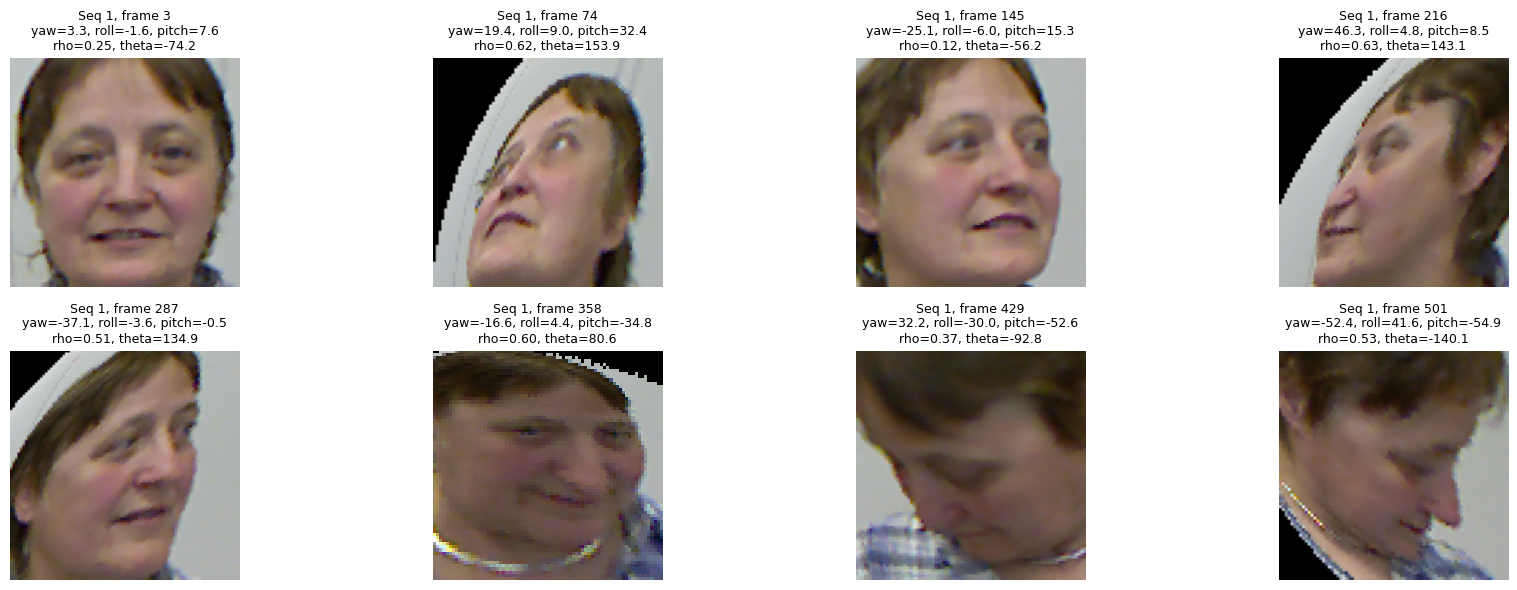

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample_sequence_id = 1
sample_df = df[df["sequence_id"] == sample_sequence_id].reset_index(drop=True)

sample_indices = np.linspace(0, len(sample_df) - 1, 8, dtype=int)
sample_rows = sample_df.iloc[sample_indices]

plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Seq {int(row['sequence_id'])}, frame {int(row['frame_id'])}\n"
        f"yaw={row['yaw']:.1f}, roll={row['roll']:.1f}, pitch={row['pitch']:.1f}\n"
        f"rho={row['rho']:.2f}, theta={row['theta']:.1f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 4. Ground-truth temporal dynamics

Since our project focuses on video-based head pose estimation, we first analyze the temporal behavior of the ground-truth annotations. This allows us to understand how yaw, roll and pitch evolve across each BIWI-360 sequence.

We also compute a simple frame-to-frame motion magnitude based on the change in the three head pose angles. This will later help us identify fast-rotation regions, where temporal smoothing may reduce jitter but can also introduce lag.

Sequences sorted by average ground-truth frame-to-frame motion:


,sequence_id,num_frames,mean_abs_d_yaw,mean_abs_d_roll,mean_abs_d_pitch,mean_motion,max_motion
5,6,542,1.604304,1.769256,1.881088,3.525679,89.319183
20,21,634,1.466508,1.832553,1.634285,3.381508,23.939624
17,18,614,1.552501,1.403594,1.482300,3.004947,39.506805
22,23,569,1.509717,1.394925,1.272115,2.834752,49.203724
14,15,654,1.480130,1.502836,1.131363,2.782862,12.895282
18,19,502,1.508842,1.298426,1.083966,2.664223,11.023587
13,14,797,1.524503,1.352240,0.987444,2.616162,9.800047
16,17,395,1.476455,1.186578,1.031588,2.537387,15.323107
15,16,914,1.351605,1.160932,1.205906,2.505490,28.953744
23,24,492,1.499251,0.575445,1.281401,2.421893,21.873022


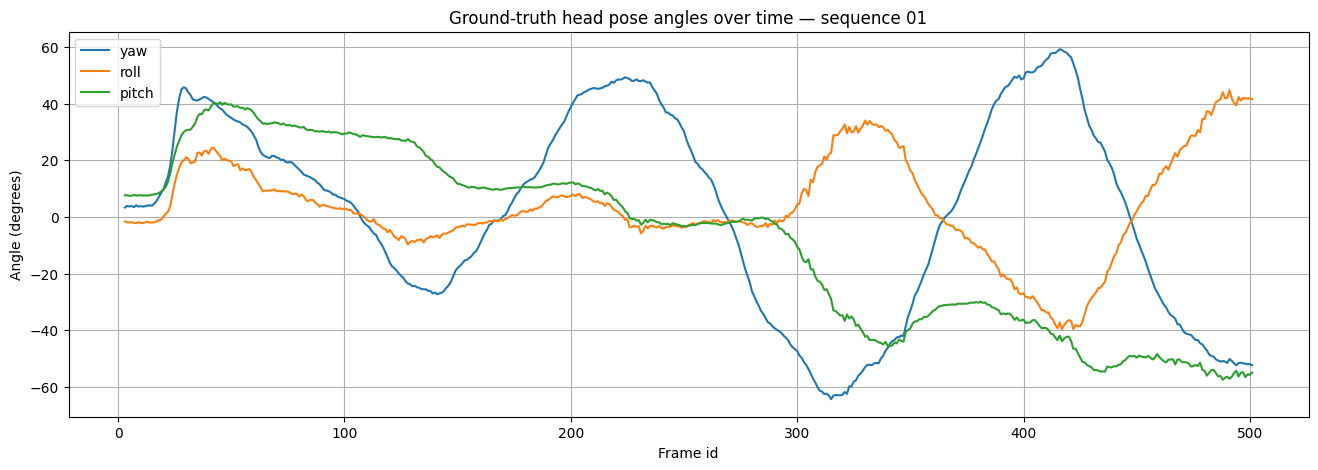

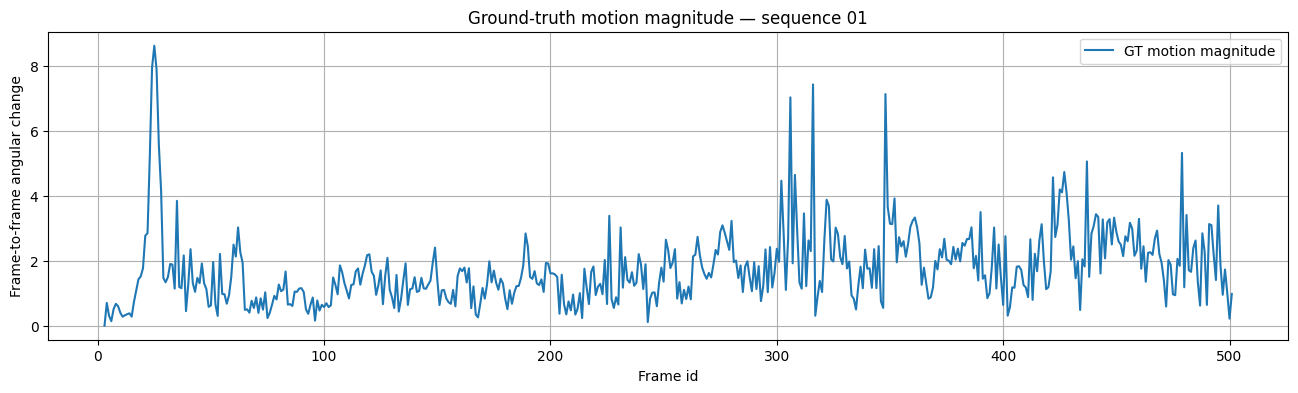

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_temporal_deltas(dataframe):
    df_out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        df_out[f"d_{angle}"] = df_out.groupby("sequence_id")[angle].diff()
        df_out[f"abs_d_{angle}"] = df_out[f"d_{angle}"].abs()
    
    df_out["gt_motion_magnitude"] = np.sqrt(
        df_out["d_yaw"].fillna(0) ** 2 +
        df_out["d_roll"].fillna(0) ** 2 +
        df_out["d_pitch"].fillna(0) ** 2
    )
    
    return df_out

df = add_temporal_deltas(df)

motion_summary = (
    df.groupby("sequence_id")
    .agg(
        num_frames=("frame_id", "count"),
        mean_abs_d_yaw=("abs_d_yaw", "mean"),
        mean_abs_d_roll=("abs_d_roll", "mean"),
        mean_abs_d_pitch=("abs_d_pitch", "mean"),
        mean_motion=("gt_motion_magnitude", "mean"),
        max_motion=("gt_motion_magnitude", "max"),
    )
    .reset_index()
    .sort_values("mean_motion", ascending=False)
)

print("Sequences sorted by average ground-truth frame-to-frame motion:")
display(motion_summary)

# Plot one representative sequence
sample_sequence_id = 1
seq_df = df[df["sequence_id"] == sample_sequence_id].sort_values("frame_id").reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(seq_df["frame_id"], seq_df["yaw"], label="yaw")
plt.plot(seq_df["frame_id"], seq_df["roll"], label="roll")
plt.plot(seq_df["frame_id"], seq_df["pitch"], label="pitch")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth head pose angles over time — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(seq_df["frame_id"], seq_df["gt_motion_magnitude"], label="GT motion magnitude")
plt.xlabel("Frame id")
plt.ylabel("Frame-to-frame angular change")
plt.title(f"Ground-truth motion magnitude — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()

### 4.1 Inspecting high-motion events

The previous summary shows that some sequences contain much larger frame-to-frame pose changes than others. Before using these values to define fast-rotation regions, we inspect the largest motion events directly.

This helps us distinguish between genuine fast head rotations and possible annotation discontinuities or isolated outlier frames.

In [10]:
# Add previous frame information to inspect temporal continuity
df = df.sort_values(["sequence_id", "frame_id"]).copy()
df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

top_motion_events = (
    df.dropna(subset=["prev_frame_id"])
    .sort_values("gt_motion_magnitude", ascending=False)
    .head(15)
    .copy()
)

cols_to_show = [
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "gt_motion_magnitude", "rho", "theta"
]

print("Top frame-to-frame ground-truth motion events:")
display(top_motion_events[cols_to_show])

Top frame-to-frame ground-truth motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,gt_motion_magnitude,rho,theta
3795,6,364.0,389,25.0,21.347407,7.994134,66.860206,44.136246,-5.617533,77.449026,89.319183,0.211457,-18.920760
15130,23,512.0,579,67.0,28.157506,3.792424,21.993601,44.477462,-17.601795,11.529899,49.203724,0.481628,-73.632074
1682,3,674.0,683,9.0,12.241342,6.473249,-29.950556,40.091381,-14.879265,-1.948867,42.807819,0.322851,42.022116
12197,18,586.0,657,71.0,14.427515,-14.353755,13.944971,17.299827,-27.786437,-22.122783,39.506805,0.623778,-75.652655
12239,18,698.0,735,37.0,20.089098,33.500744,27.444129,28.645330,25.186956,-7.132467,38.804765,0.503953,-49.958129
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
11191,16,853.0,884,31.0,38.345789,3.644984,32.114347,25.076622,7.759899,3.638653,26.500807,0.557330,-23.373476
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
15132,23,580.0,773,193.0,1.044262,-0.306037,17.738829,-25.391873,-3.431417,-3.175609,25.818721,0.377761,51.268127


### 4.2 Handling frame gaps

The inspection of high-motion events shows that some large pose changes occur when the frame id jumps by more than one. Therefore, these events are not true one-frame changes, but changes between two available annotated frames separated by a temporal gap.

To avoid overestimating fast motion, we separate two concepts:

- `observed_motion_magnitude`: angular change between two consecutive available rows in the dataset.
- `motion_per_frame`: the same angular change normalized by the frame id gap.
- `consecutive_motion_magnitude`: angular change only when the frame gap is exactly 1.

For temporal jitter analysis, we will mainly rely on consecutive-frame pairs, because they represent the actual frame-to-frame behavior of the sequence.

In [11]:
# Recompute temporal quantities while explicitly handling frame gaps
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

for angle in ["yaw", "roll", "pitch"]:
    df[f"d_{angle}"] = df.groupby("sequence_id")[angle].diff()
    df[f"abs_d_{angle}"] = df[f"d_{angle}"].abs()

df["observed_motion_magnitude"] = np.sqrt(
    df["d_yaw"].fillna(0) ** 2 +
    df["d_roll"].fillna(0) ** 2 +
    df["d_pitch"].fillna(0) ** 2
)

df["motion_per_frame"] = df["observed_motion_magnitude"] / df["frame_gap"]

df["is_consecutive_pair"] = df["frame_gap"] == 1

df["consecutive_motion_magnitude"] = np.where(
    df["is_consecutive_pair"],
    df["observed_motion_magnitude"],
    np.nan
)

gap_summary = (
    df.dropna(subset=["frame_gap"])
    .groupby("sequence_id")
    .agg(
        num_pairs=("frame_gap", "count"),
        consecutive_pairs=("is_consecutive_pair", "sum"),
        non_consecutive_pairs=("is_consecutive_pair", lambda x: (~x).sum()),
        max_frame_gap=("frame_gap", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
        max_consecutive_motion=("consecutive_motion_magnitude", "max"),
        mean_motion_per_frame=("motion_per_frame", "mean"),
        max_motion_per_frame=("motion_per_frame", "max"),
    )
    .reset_index()
    .sort_values("mean_consecutive_motion", ascending=False)
)

print("Frame gap and corrected motion summary:")
display(gap_summary)

print("\nLargest true consecutive-frame motion events:")
display(
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .head(15)[
        [
            "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
            "yaw", "roll", "pitch",
            "d_yaw", "d_roll", "d_pitch",
            "consecutive_motion_magnitude",
            "rho", "theta"
        ]
    ]
)

Frame gap and corrected motion summary:


,sequence_id,num_pairs,consecutive_pairs,non_consecutive_pairs,max_frame_gap,mean_consecutive_motion,max_consecutive_motion,mean_motion_per_frame,max_motion_per_frame
5,6,541,539,2,34.0,3.361788,18.854102,3.356486,18.854102
20,21,633,628,5,56.0,3.297967,23.939624,3.281727,23.939624
17,18,613,609,4,71.0,2.849727,26.265295,2.836422,26.265295
14,15,653,651,2,30.0,2.783583,12.895282,2.775543,12.895282
22,23,568,566,2,193.0,2.717228,11.919311,2.709189,11.919311
18,19,501,500,1,22.0,2.669663,11.023587,2.664571,11.023587
13,14,796,796,0,1.0,2.619449,9.800047,2.619449,9.800047
16,17,394,392,2,45.0,2.492552,15.323107,2.481408,15.323107
15,16,913,911,2,31.0,2.471317,28.953744,2.467505,28.953744
23,24,491,489,2,84.0,2.362625,10.669820,2.354259,10.669820



Largest true consecutive-frame motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,consecutive_motion_magnitude,rho,theta
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
11048,16,710.0,711,1.0,1.993040,23.932825,-11.547316,-15.563452,15.706857,10.507836,24.481443,0.126256,-56.713146
13457,21,138.0,139,1.0,-69.553207,2.718918,18.317681,-0.374926,-18.473249,15.221829,23.939624,0.090083,-18.011050
13670,21,358.0,359,1.0,3.818794,3.343178,62.249247,15.104764,-15.872656,0.661997,21.921071,0.714871,-38.537136
3293,5,811.0,812,1.0,-9.168125,6.079890,-43.387302,18.768912,-10.637561,0.148096,21.574329,0.687212,-143.537217
3411,5,929.0,930,1.0,-42.499984,14.562829,-22.977119,-2.304236,-9.910234,18.007334,20.682996,0.114303,-71.034853
11043,16,705.0,706,1.0,16.849036,-28.826517,-1.851251,4.627685,2.113813,-18.192720,18.890705,0.423010,-39.128496
3547,6,116.0,117,1.0,-74.670407,17.289399,6.903782,0.219121,14.224531,-12.373029,18.854102,0.223681,49.871457


### 4.3 Visual inspection of a true high-motion event

After correcting for frame gaps, the largest true consecutive-frame motion event occurs between two adjacent frames. We now inspect a short temporal window around that event.

This visualization helps us check whether the large angular change corresponds to an actual visual change in head pose or whether it may be caused by annotation noise, image distortion, or another dataset artifact.

Selected high-motion event:


sequence_id                            16
prev_frame_id                       699.0
frame_id                              700
frame_gap                             1.0
yaw                             -4.531611
roll                            -23.32848
pitch                           62.114505
d_yaw                           11.837307
d_roll                          -23.14425
d_pitch                         12.749163
consecutive_motion_magnitude    28.953744
rho                              0.401233
theta                           46.038523
Name: 11037, dtype: object


Temporal window around the event:


,sequence_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta
0,16,695,-3.849287,31.068011,17.068826,13.329200,0.043766,28.512174
1,16,696,-9.902146,28.386931,26.230939,11.303522,0.338310,154.639296
2,16,697,-13.112218,19.612712,35.943585,13.476905,0.029792,-35.893442
3,16,698,-11.159914,10.880800,45.226339,12.892916,0.007660,-13.499510
4,16,699,-16.368918,-0.184230,49.365342,12.911234,0.473448,-61.062751
5,16,700,-4.531611,-23.328480,62.114505,28.953744,0.401233,46.038523
6,16,701,-10.522929,-23.648027,62.986291,6.062839,0.500654,3.090260
7,16,702,1.660177,-28.409034,53.114007,16.387717,0.566981,77.256481
8,16,703,0.707695,-27.548295,45.644887,7.578644,0.607540,45.629462
9,16,704,5.593080,-28.812741,32.310065,14.257745,0.122861,-157.322498


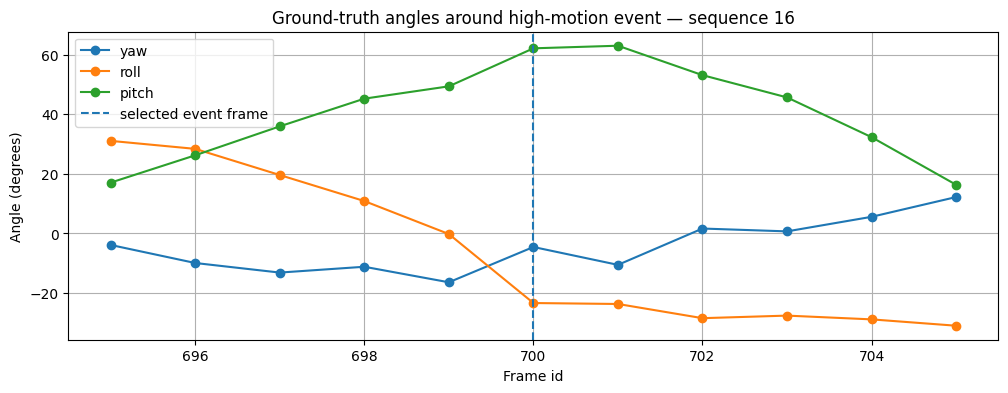

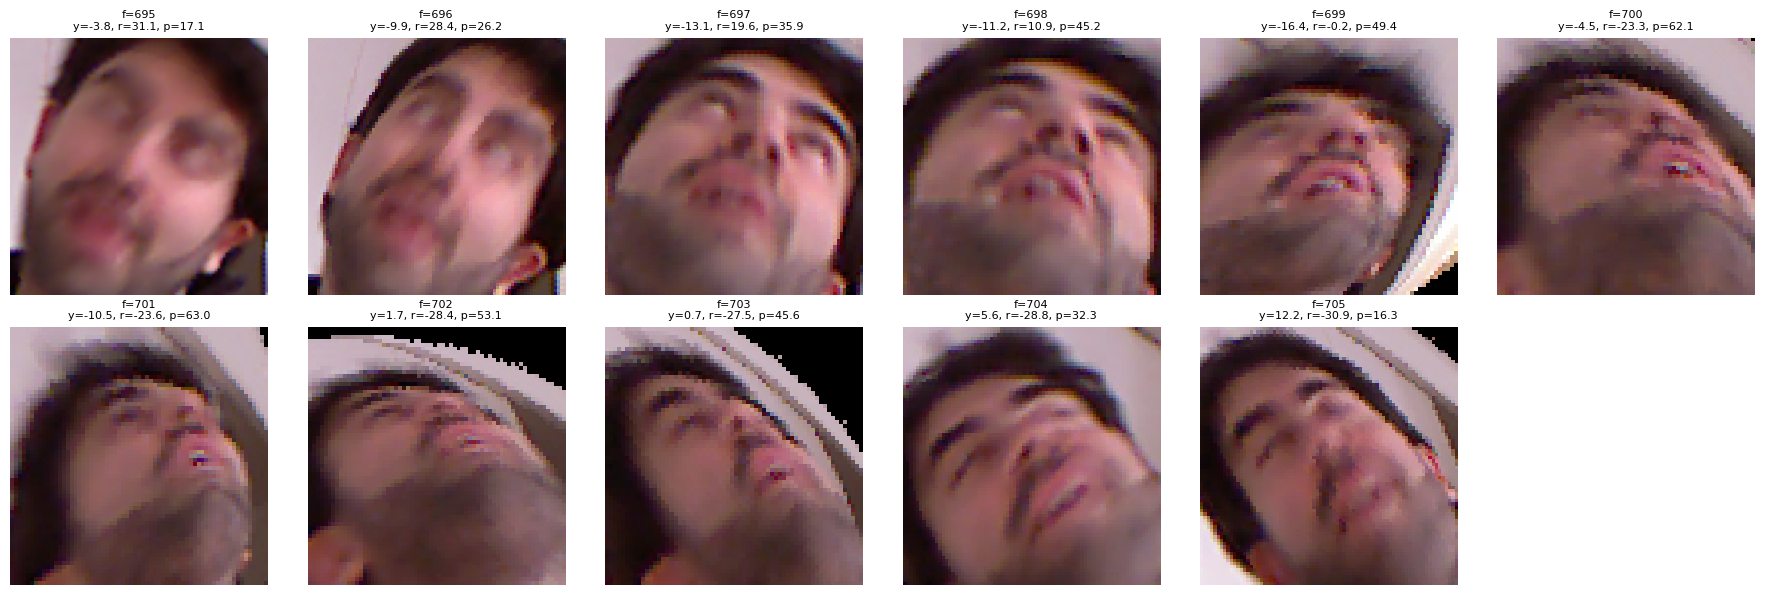

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Select the largest true consecutive-frame motion event
event = (
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .iloc[0]
)

event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 5

event_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print("Selected high-motion event:")
display(event[[
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

print("\nTemporal window around the event:")
display(event_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

# Plot angle trajectories in the local window
plt.figure(figsize=(12, 4))
plt.plot(event_window["frame_id"], event_window["yaw"], marker="o", label="yaw")
plt.plot(event_window["frame_id"], event_window["roll"], marker="o", label="roll")
plt.plot(event_window["frame_id"], event_window["pitch"], marker="o", label="pitch")
plt.axvline(event_frame, linestyle="--", label="selected event frame")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth angles around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

# Visualize frames around the event
num_frames_to_show = min(len(event_window), 12)
plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(event_window.iloc[:num_frames_to_show].iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"f={int(row['frame_id'])}\n"
        f"y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 4.4 Temporal behavior of fisheye distortion metadata

The visual inspection suggests that some apparent temporal changes may be influenced not only by head motion, but also by changes in the fisheye distortion parameters.

In BIWI-360, `rho` represents the normalized radial position used to generate the fisheye distortion, while `theta` represents the angular position in degrees. Since these values may vary from frame to frame, the visual input can change even when the underlying head pose changes smoothly.

We therefore inspect the temporal variation of `rho` and `theta`. This is important because prediction jitter may be caused by both head motion and frame-level distortion changes.

Temporal variation of fisheye distortion metadata in consecutive frame pairs:


,sequence_id,mean_abs_d_rho,max_abs_d_rho,mean_abs_d_theta,max_abs_d_theta,mean_consecutive_motion
1,2,0.293180,0.778485,92.099688,179.999919,1.465451
21,22,0.281305,0.773895,90.469284,179.771440,1.659451
22,23,0.277830,0.786281,89.114111,178.481651,2.717228
15,16,0.276735,0.780543,89.506495,179.801341,2.471317
23,24,0.276229,0.784355,90.746203,179.897569,2.362625
7,8,0.274179,0.784896,89.205556,179.978416,1.718165
20,21,0.274110,0.773897,86.763201,179.761454,3.297967
14,15,0.272847,0.784782,90.904430,179.945849,2.783583
11,12,0.270826,0.775445,91.189305,179.492981,1.085571
16,17,0.270562,0.759482,86.085297,179.631652,2.492552


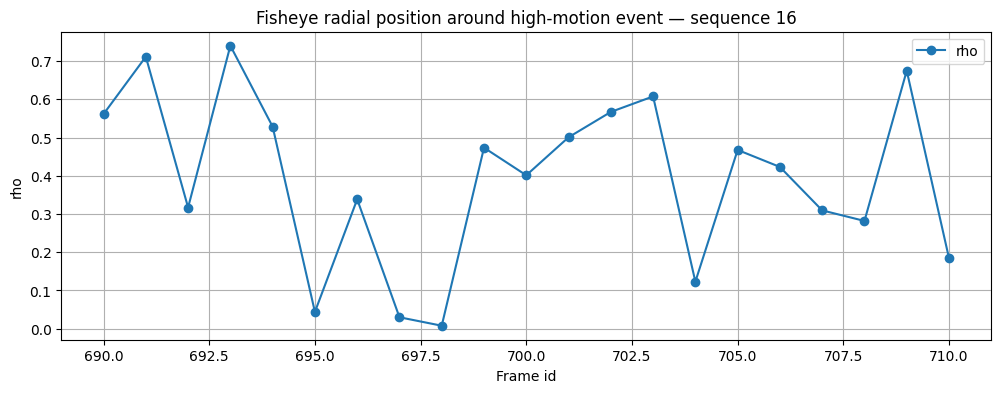

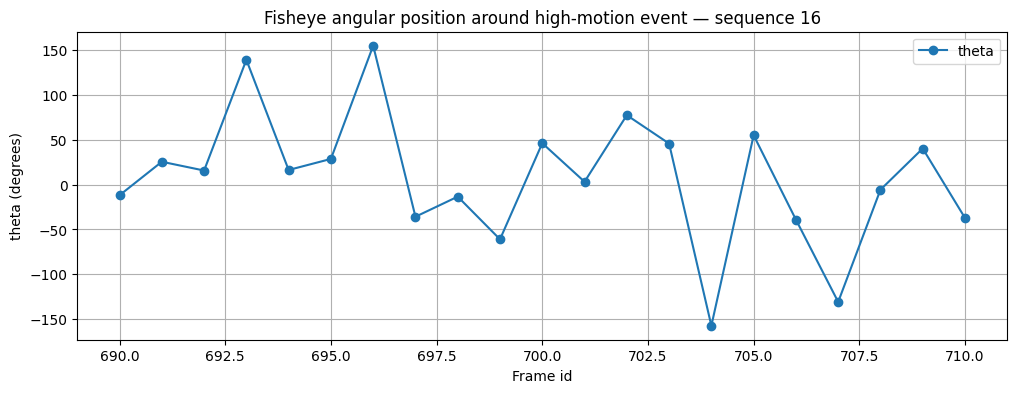

Fisheye metadata around the selected event:


,sequence_id,frame_id,yaw,roll,pitch,rho,theta,abs_d_rho,abs_d_theta_circular,consecutive_motion_magnitude
0,16,690,20.358862,-9.042987,-16.822059,0.561373,-11.948805,0.215088,30.080060,10.257547
1,16,691,16.694705,2.476415,-14.645219,0.711456,25.365397,0.150083,37.314202,12.282562
2,16,692,14.164224,12.970270,-9.381875,0.316937,15.582250,0.394519,9.783147,12.009459
3,16,693,10.273026,24.010633,-1.459435,0.740184,138.952373,0.423248,123.370123,14.134924
4,16,694,4.095913,29.027902,6.562670,0.528453,16.194854,0.211731,122.757519,11.299729
5,16,695,-3.849287,31.068011,17.068826,0.043766,28.512174,0.484687,12.317321,13.329200
6,16,696,-9.902146,28.386931,26.230939,0.338310,154.639296,0.294544,126.127122,11.303522
7,16,697,-13.112218,19.612712,35.943585,0.029792,-35.893442,0.308517,169.467262,13.476905
8,16,698,-11.159914,10.880800,45.226339,0.007660,-13.499510,0.022132,22.393931,12.892916
9,16,699,-16.368918,-0.184230,49.365342,0.473448,-61.062751,0.465788,47.563240,12.911234


In [13]:
# Compute temporal changes in fisheye metadata
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["d_rho"] = df.groupby("sequence_id")["rho"].diff()
df["abs_d_rho"] = df["d_rho"].abs()

# Circular difference for theta in degrees
def circular_angle_diff_deg(current, previous):
    diff = current - previous
    return (diff + 180) % 360 - 180

df["prev_theta"] = df.groupby("sequence_id")["theta"].shift(1)
df["d_theta_circular"] = circular_angle_diff_deg(df["theta"], df["prev_theta"])
df["abs_d_theta_circular"] = df["d_theta_circular"].abs()

fisheye_summary = (
    df[df["is_consecutive_pair"]]
    .groupby("sequence_id")
    .agg(
        mean_abs_d_rho=("abs_d_rho", "mean"),
        max_abs_d_rho=("abs_d_rho", "max"),
        mean_abs_d_theta=("abs_d_theta_circular", "mean"),
        max_abs_d_theta=("abs_d_theta_circular", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_d_rho", ascending=False)
)

print("Temporal variation of fisheye distortion metadata in consecutive frame pairs:")
display(fisheye_summary)

# Plot fisheye metadata around the high-motion event already selected
event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 10

fisheye_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["rho"], marker="o", label="rho")
plt.xlabel("Frame id")
plt.ylabel("rho")
plt.title(f"Fisheye radial position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["theta"], marker="o", label="theta")
plt.xlabel("Frame id")
plt.ylabel("theta (degrees)")
plt.title(f"Fisheye angular position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

print("Fisheye metadata around the selected event:")
display(fisheye_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "rho", "theta",
    "abs_d_rho", "abs_d_theta_circular",
    "consecutive_motion_magnitude"
]])

### 4.5 Defining temporal analysis regimes

The previous analysis shows that BIWI-360 preserves the sequential structure of BIWI, but the fisheye distortion metadata can vary strongly from one frame to the next. Therefore, temporal instability may come from two different sources:

1. actual head pose motion;
2. frame-level changes in fisheye distortion.

To make the later evaluation more interpretable, we define temporal regimes using only consecutive frame pairs. We classify each pair according to its ground-truth pose motion and its fisheye distortion change. This will allow us to compare model behavior in relatively stable conditions versus more challenging high-motion or high-distortion-change regions.


In [14]:
# Build a clean table of true consecutive frame pairs for temporal analysis
temporal_pairs = df[df["is_consecutive_pair"]].copy().reset_index(drop=True)

# Normalized fisheye change:
# - rho is in [0, 0.8], so we normalize by 0.8
# - theta circular difference is in [0, 180], so we normalize by 180
temporal_pairs["fisheye_change"] = np.sqrt(
    (temporal_pairs["abs_d_rho"] / 0.8) ** 2 +
    (temporal_pairs["abs_d_theta_circular"] / 180.0) ** 2
)

# Define thresholds using quantiles rather than fixed arbitrary values
motion_q75 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.75)
motion_q90 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.90)

fisheye_q75 = temporal_pairs["fisheye_change"].quantile(0.75)
fisheye_q90 = temporal_pairs["fisheye_change"].quantile(0.90)

def assign_level(value, q75, q90):
    if value >= q90:
        return "high"
    elif value >= q75:
        return "medium"
    else:
        return "low"

temporal_pairs["motion_level"] = temporal_pairs["consecutive_motion_magnitude"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

temporal_pairs["fisheye_change_level"] = temporal_pairs["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of consecutive frame pairs:", len(temporal_pairs))

print("\nMotion thresholds:")
print(f"75th percentile: {motion_q75:.3f}")
print(f"90th percentile: {motion_q90:.3f}")

print("\nFisheye-change thresholds:")
print(f"75th percentile: {fisheye_q75:.3f}")
print(f"90th percentile: {fisheye_q90:.3f}")

print("\nMotion level counts:")
display(temporal_pairs["motion_level"].value_counts().rename_axis("motion_level").reset_index(name="count"))

print("\nFisheye-change level counts:")
display(temporal_pairs["fisheye_change_level"].value_counts().rename_axis("fisheye_change_level").reset_index(name="count"))

print("\nJoint regime counts:")
display(
    temporal_pairs
    .groupby(["motion_level", "fisheye_change_level"])
    .size()
    .reset_index(name="count")
    .sort_values(["motion_level", "fisheye_change_level"])
)

print("\nExample high-motion and high-distortion-change pairs:")
display(
    temporal_pairs[
        (temporal_pairs["motion_level"] == "high") &
        (temporal_pairs["fisheye_change_level"] == "high")
    ][[
        "sequence_id", "prev_frame_id", "frame_id",
        "yaw", "roll", "pitch",
        "consecutive_motion_magnitude",
        "rho", "theta",
        "abs_d_rho", "abs_d_theta_circular",
        "fisheye_change",
        "motion_level", "fisheye_change_level"
    ]].head(10)
)

Number of consecutive frame pairs: 15628

Motion thresholds:
75th percentile: 2.535
90th percentile: 3.914

Fisheye-change thresholds:
75th percentile: 0.867
90th percentile: 0.996

Motion level counts:


,motion_level,count
0,low,11721
1,medium,2344
2,high,1563



Fisheye-change level counts:


,fisheye_change_level,count
0,low,11721
1,medium,2344
2,high,1563



Joint regime counts:


,motion_level,fisheye_change_level,count
0,high,high,140
1,high,low,1159
2,high,medium,264
3,low,high,1187
4,low,low,8785
5,low,medium,1749
6,medium,high,236
7,medium,low,1777
8,medium,medium,331



Example high-motion and high-distortion-change pairs:


,sequence_id,prev_frame_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta,abs_d_rho,abs_d_theta_circular,fisheye_change,motion_level,fisheye_change_level
19,1,22.0,23,17.959581,3.643839,15.247137,5.190434,0.103492,-152.658969,0.382351,158.168564,1.000282,high,high
304,1,307.0,308,-58.462280,15.803192,-21.067019,4.645668,0.258720,38.310167,0.540472,170.311493,1.162613,high,high
423,1,426.0,427,37.767735,-34.432472,-51.356571,4.733204,0.583560,10.015673,0.477031,161.111619,1.075500,high,high
833,2,338.0,339,-12.293116,21.179186,-53.616307,3.928912,0.158102,132.488993,0.528819,168.016834,1.143782,high,high
841,2,346.0,347,-5.046678,9.913918,-53.507912,4.050873,0.269263,-52.965853,0.308319,171.233517,1.026401,high,high
853,2,358.0,359,4.965018,-12.767263,-52.496013,5.210252,0.013459,-149.857898,0.718725,135.420136,1.171810,high,high
976,2,481.0,482,27.644811,-15.283466,-25.475475,4.471715,0.747373,166.805707,0.624250,134.182182,1.079163,high,high
1301,3,296.0,297,41.108193,25.703239,34.478895,4.106855,0.017811,-9.005829,0.398731,157.882408,1.008843,high,high
1411,3,406.0,407,-22.565788,-2.168420,12.432658,11.369611,0.072981,-158.419832,0.715091,128.635670,1.144424,high,high
1862,4,129.0,130,50.774036,33.549748,42.305406,5.000673,0.210213,25.409452,0.516394,160.001848,1.098546,high,high


## 5. Dataset analysis summary

The dataset inspection confirms that BIWI-360 contains 15,678 RGB frames organized into 24 video sequences, with one annotation row per available frame. All image paths referenced by the annotation table were found successfully.

The labels provide yaw, roll and pitch angles, together with two fisheye distortion metadata values: `rho`, the normalized radial position, and `theta`, the angular position in degrees. These metadata values are important because the fisheye transformation is not temporally smooth: both `rho` and `theta` can change strongly between consecutive frames.

For this reason, we will evaluate temporal behavior using only true consecutive frame pairs, where the frame gap is exactly one. We also define motion and fisheye-change regimes using quantile-based thresholds. This allows us to compare model behavior under low-motion, high-motion, low-distortion-change and high-distortion-change conditions.

This analysis reveals an important limitation of BIWI-360 for video-based evaluation: although the head pose sequence is temporal, the fisheye distortion may vary independently from frame to frame. Therefore, prediction instability can be caused by both actual head motion and artificial changes in image geometry.

In [15]:
import sys
import platform
import torch
from pathlib import Path

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("CUDA is available.")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Inference will run on CPU unless GPU is enabled.")

print("\nCurrent working directory:")
print(Path.cwd())

print("\nKaggle input root exists:", Path("/kaggle/input").exists())
print("Kaggle working directory exists:", Path("/kaggle/working").exists())

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch version: 2.10.0+cu128
CUDA is available.
GPU: Tesla T4

Current working directory:
/kaggle/working

Kaggle input root exists: True
Kaggle working directory exists: True


## 6. Model setup strategy

We will use a pretrained 6D head pose estimator as a frame-by-frame baseline. Before downloading or loading any external repository, we check whether internet access is available in the Kaggle environment and whether any pretrained model weights are already attached as Kaggle inputs.

This keeps the notebook reproducible and avoids hidden assumptions about the runtime environment.

In [16]:
import urllib.request
from pathlib import Path

# Check internet access without crashing the notebook
def check_url_available(url, timeout=10):
    try:
        with urllib.request.urlopen(url, timeout=timeout) as response:
            return True, response.status
    except Exception as e:
        return False, str(e)

github_ok, github_status = check_url_available("https://github.com", timeout=10)

print("Internet check:")
print("GitHub reachable:", github_ok)
print("Status / error:", github_status)

# Search for possible pretrained model files already attached as Kaggle inputs
#model_extensions = {".pt", ".pth", ".pkl", ".onnx", ".ckpt"}

model_files = []
for path in Path("/kaggle/input").rglob("*"):
    if path.is_file() and path.suffix.lower() in model_extensions:
        model_files.append(path)

print("\nPotential model files found in /kaggle/input:")
if model_files:
    for path in model_files[:50]:
        print(" -", path)
else:
    print("No model weight files were found in the attached Kaggle inputs.")

Internet check:
GitHub reachable: True
Status / error: 200


KeyboardInterrupt: 

### 6.1 Cloning the 6DRepNet360 repository

Since GitHub is reachable from the Kaggle environment, we clone the official 6DRepNet360 repository and inspect its contents. We first check the available files before deciding how to load the pretrained model.

This makes the model setup explicit and reproducible inside the notebook.

In [17]:
import subprocess
from pathlib import Path

EXTERNAL_DIR = Path("/kaggle/working/external")
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

REPO_DIR = EXTERNAL_DIR / "6DRepNet360"
REPO_URL = "https://github.com/thohemp/6DRepNet360.git"

if REPO_DIR.exists():
    print("Repository already exists:", REPO_DIR)
else:
    print("Cloning repository...")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        capture_output=True,
        text=True
    )
    print("Return code:", result.returncode)
    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)
    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

print("\nRepository directory:")
print(REPO_DIR)

print("\nTop-level repository files:")
for path in sorted(REPO_DIR.iterdir()):
    print(" -", path.name)

print("\nCurrent repository commit:")
commit_result = subprocess.run(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
    capture_output=True,
    text=True
)
print(commit_result.stdout.strip())

Cloning repository...
Return code: 0

STDERR:
Cloning into '/kaggle/working/external/6DRepNet360'...


Repository directory:
/kaggle/working/external/6DRepNet360

Top-level repository files:
 - .git
 - LICENSE.MD
 - README.MD
 - sixdrepnet360

Current repository commit:
b06e4fed77f802fbf05319b85bb65215087d5c7a


### 6.2 Inspecting the repository structure

After cloning the official 6DRepNet360 repository, we inspect its README and source files before importing the package. This allows us to understand the expected API, dependencies, and pretrained model loading mechanism without making assumptions.

In [18]:
from pathlib import Path

readme_path = REPO_DIR / "README.MD"

print("README exists:", readme_path.exists())

if readme_path.exists():
    readme_text = readme_path.read_text(errors="ignore")
    print("\nREADME preview:")
    print("=" * 100)
    print(readme_text[:6000])
    print("=" * 100)

print("\nRepository tree preview:")
for path in sorted(REPO_DIR.rglob("*")):
    relative = path.relative_to(REPO_DIR)
    depth = len(relative.parts)
    if depth <= 3:
        prefix = "  " * (depth - 1)
        print(f"{prefix}- {relative}")

README exists: True

README preview:
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-biwi)](https://paperswithcode.com/sota/head-pose-estimation-on-biwi?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-cmu-panoptic-300w-lp)](https://paperswithcode.com/sota/head-pose-estimation-on-cmu-panoptic-300w-lp?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-aflw2000)](https://paperswithcode.com/sota/head-pose-estimation-on-aflw2000?p=towards-robust-and-unconstrained-full-range)
# <div align="center"> **6DRepNet360** </div>

<p align="center">
  <img src="https://github.com/thohemp/archive/blob/main/6drepnet

### 6.3 Inspecting the 6DRepNet360 source code

The official README does not yet provide detailed usage instructions, so we inspect the available Python files before importing the model. This helps us understand whether the repository includes the model architecture, the inference pipeline, and the required preprocessing functions.

In [19]:
source_files = [
    REPO_DIR / "sixdrepnet360" / "test.py",
    REPO_DIR / "sixdrepnet360" / "utils.py",
    REPO_DIR / "sixdrepnet360" / "datasets.py",
]

for file_path in source_files:
    print("=" * 120)
    print(file_path)
    print("=" * 120)
    
    if file_path.exists():
        text = file_path.read_text(errors="ignore")
        print(text[:8000])
    else:
        print("File not found.")
    
    print("\n")

/kaggle/working/external/6DRepNet360/sixdrepnet360/test.py
import math
from matplotlib import pyplot as plt
import sys
import os
import argparse

import numpy as np
import cv2
from torchvision.utils import make_grid

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.backends.cudnn as cudnn
import torchvision
import torch.nn.functional as F
import datasets
import utils
from torch.hub import load_state_dict_from_url

#matplotlib.use("gtk")


class SixDRepNet360(nn.Module):
    def __init__(self, block, layers, fc_layers=1):
        self.inplanes = 64
        super(SixDRepNet360, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[

### 6.4 Importing the model definition

The repository defines the `SixDRepNet360` architecture inside `test.py`. The model predicts a 6D rotation representation and then converts it into a valid 3D rotation matrix using the utility function `compute_rotation_matrix_from_ortho6d`.

We now import the model definition and instantiate the network on the available device. At this stage, we only check that the architecture can be created successfully; pretrained weights will be loaded in the next step.

In [21]:
import sys
import importlib
from pathlib import Path

import torch
import torchvision

SIXD_SRC_DIR = REPO_DIR / "sixdrepnet360"

# Add the source directory to Python path so that test.py can import utils.py and datasets.py
if str(SIXD_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SIXD_SRC_DIR))

# Import repository modules
sixd_test = importlib.import_module("test")
sixd_utils = importlib.import_module("utils")

# Create model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = sixd_test.SixDRepNet360(
    torchvision.models.resnet.Bottleneck,
    [3, 4, 6, 3],
    6
).to(device)

model.eval()

num_params = sum(p.numel() for p in model.parameters())
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Device:", device)
print("Model created successfully.")
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable_params:,}")

Device: cuda
Model created successfully.
Total parameters: 23,520,326
Trainable parameters: 23,520,326


### 6.5 Loading pretrained 6DRepNet360 weights

We use the official pretrained 6DRepNet360 Full Rotation weights. This model was fine-tuned on 300W-LP and CMU Panoptic, which makes it more suitable for wide-range head pose estimation than a model trained only on 300W-LP.

The model will be used as a frame-by-frame baseline. We do not fine-tune it on BIWI-360; instead, we evaluate how well a pretrained 6D rotation-based estimator transfers to fisheye-distorted video frames.

In [22]:
from torch.hub import load_state_dict_from_url

WEIGHTS_URL = "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth"

print("Downloading/loading pretrained weights...")
saved_state_dict = load_state_dict_from_url(
    WEIGHTS_URL,
    model_dir="/kaggle/working/model_weights",
    map_location=device,
    progress=True
)

if "model_state_dict" in saved_state_dict:
    state_dict = saved_state_dict["model_state_dict"]
else:
    state_dict = saved_state_dict

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

model.to(device)
model.eval()

print("Pretrained weights loaded.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)

Downloading/loading pretrained weights...
Downloading: "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth" to /kaggle/working/model_weights/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth


100%|██████████| 90.0M/90.0M [00:04<00:00, 21.9MB/s]


Pretrained weights loaded.
Missing keys: []
Unexpected keys: []


### 6.6 Single-frame inference test

Before running inference on the full BIWI-360 dataset, we test the complete prediction pipeline on a single frame. This allows us to verify the preprocessing, model output format, Euler angle conversion, and comparison with the ground-truth annotation.

The model outputs a rotation matrix. We convert it to Euler angles using the repository utility function and then report yaw, roll and pitch in degrees.

Single-frame inference test
Image: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360/01/frame_00003_rgb.png

Ground truth:
yaw   = 3.29
roll  = -1.57
pitch = 7.61

Prediction:
yaw   = -3.89
roll  = -3.66
pitch = -9.67

Absolute angular error:
yaw   = 7.18
roll  = 2.10
pitch = 17.27


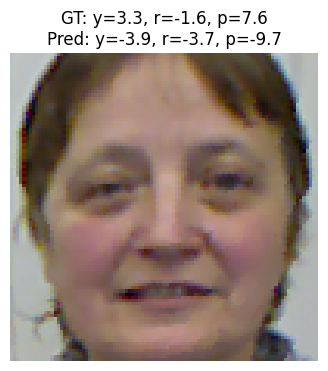

In [23]:
from torchvision import transforms
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# Same preprocessing used in the official test script
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def angular_error_deg(pred, gt):
    """Smallest absolute angular difference in degrees."""
    return min(abs(pred - gt), abs(pred + 360 - gt), abs(pred - 360 - gt))

def predict_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        rotation_matrix = model(input_tensor)
        euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrix)
        euler_deg = euler[0].detach().cpu().numpy() * 180.0 / np.pi
    
    # Repository convention:
    # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
    pred_pitch = float(euler_deg[0])
    pred_yaw = float(euler_deg[1])
    pred_roll = float(euler_deg[2])
    
    return {
        "pred_yaw": pred_yaw,
        "pred_roll": pred_roll,
        "pred_pitch": pred_pitch,
    }

# Select one example frame
sample_row = df.iloc[0]
prediction = predict_single_image(sample_row["image_path"])

print("Single-frame inference test")
print("Image:", sample_row["image_path"])
print()

print("Ground truth:")
print(f"yaw   = {sample_row['yaw']:.2f}")
print(f"roll  = {sample_row['roll']:.2f}")
print(f"pitch = {sample_row['pitch']:.2f}")
print()

print("Prediction:")
print(f"yaw   = {prediction['pred_yaw']:.2f}")
print(f"roll  = {prediction['pred_roll']:.2f}")
print(f"pitch = {prediction['pred_pitch']:.2f}")
print()

print("Absolute angular error:")
print(f"yaw   = {angular_error_deg(prediction['pred_yaw'], sample_row['yaw']):.2f}")
print(f"roll  = {angular_error_deg(prediction['pred_roll'], sample_row['roll']):.2f}")
print(f"pitch = {angular_error_deg(prediction['pred_pitch'], sample_row['pitch']):.2f}")

# Visualize the tested frame
img = Image.open(sample_row["image_path"]).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"GT: y={sample_row['yaw']:.1f}, r={sample_row['roll']:.1f}, p={sample_row['pitch']:.1f}\n"
    f"Pred: y={prediction['pred_yaw']:.1f}, r={prediction['pred_roll']:.1f}, p={prediction['pred_pitch']:.1f}"
)
plt.show()

### 6.7 Checking angle convention alignment

The single-frame test suggests that some predicted angles may follow a different sign convention from the BIWI-360 labels. Before running full-dataset inference, we test several simple sign-convention variants on a small subset of frames.

This step is necessary because head pose datasets and models may use different coordinate conventions. We do not want to apply any correction manually unless it consistently reduces the error across multiple frames.

In [25]:
from tqdm.auto import tqdm
import itertools
import pandas as pd
import numpy as np

# Sample frames across the whole dataset to check convention alignment quickly
sample_eval_parts = []

for _, group in df.groupby("sequence_id"):
    sample_eval_parts.append(group.sample(min(len(group), 10), random_state=42))

sample_eval_df = pd.concat(sample_eval_parts).reset_index(drop=True)

print("Number of sampled frames:", len(sample_eval_df))

pred_rows = []

for _, row in tqdm(sample_eval_df.iterrows(), total=len(sample_eval_df)):
    pred = predict_single_image(row["image_path"])
    
    pred_rows.append({
        "sequence_id": row["sequence_id"],
        "frame_id": row["frame_id"],
        "gt_yaw": row["yaw"],
        "gt_roll": row["roll"],
        "gt_pitch": row["pitch"],
        "pred_yaw_raw": pred["pred_yaw"],
        "pred_roll_raw": pred["pred_roll"],
        "pred_pitch_raw": pred["pred_pitch"],
    })

convention_df = pd.DataFrame(pred_rows)

def mean_mae_for_signs(data, sy=1, sr=1, sp=1):
    yaw_errors = [
        angular_error_deg(sy * p, g)
        for p, g in zip(data["pred_yaw_raw"], data["gt_yaw"])
    ]
    roll_errors = [
        angular_error_deg(sr * p, g)
        for p, g in zip(data["pred_roll_raw"], data["gt_roll"])
    ]
    pitch_errors = [
        angular_error_deg(sp * p, g)
        for p, g in zip(data["pred_pitch_raw"], data["gt_pitch"])
    ]
    
    return {
        "sign_yaw": sy,
        "sign_roll": sr,
        "sign_pitch": sp,
        "mae_yaw": np.mean(yaw_errors),
        "mae_roll": np.mean(roll_errors),
        "mae_pitch": np.mean(pitch_errors),
        "mean_mae": np.mean([np.mean(yaw_errors), np.mean(roll_errors), np.mean(pitch_errors)])
    }

results = []

for sy, sr, sp in itertools.product([1, -1], repeat=3):
    results.append(mean_mae_for_signs(convention_df, sy=sy, sr=sr, sp=sp))

sign_results = pd.DataFrame(results).sort_values("mean_mae").reset_index(drop=True)

print("Sign convention comparison on sampled frames:")
display(sign_results)

print("\nSample predictions with raw model outputs:")
display(convention_df.head(10))

Number of sampled frames: 240


  0%|          | 0/240 [00:00<?, ?it/s]

Sign convention comparison on sampled frames:


,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,1,1,1,17.913169,22.210959,31.029293,23.717807
1,1,1,-1,17.913169,22.210959,41.967230,27.363786
2,1,-1,1,17.913169,33.793643,31.029293,27.578702
3,1,-1,-1,17.913169,33.793643,41.967230,31.224681
4,-1,1,1,48.381750,22.210959,31.029293,33.874001
5,-1,1,-1,48.381750,22.210959,41.967230,37.519979
6,-1,-1,1,48.381750,33.793643,31.029293,37.734895
7,-1,-1,-1,48.381750,33.793643,41.967230,41.380874



Sample predictions with raw model outputs:


,sequence_id,frame_id,gt_yaw,gt_roll,gt_pitch,pred_yaw_raw,pred_roll_raw,pred_pitch_raw
0,1,463,-31.972218,17.847537,-51.348841,-20.983072,8.452777,-34.629814
1,1,76,19.351829,8.534912,32.376030,-0.398311,-2.028677,-2.104806
2,1,234,47.351681,-4.116045,-1.959559,35.841503,2.887403,1.870802
3,1,178,10.137439,1.819631,10.255109,15.431098,4.674442,17.101084
4,1,240,39.711930,-3.933954,-2.544290,23.998280,4.107418,-13.424181
5,1,428,35.033410,-31.509099,-52.262954,-56.730854,-142.266083,177.015411
6,1,158,-12.308774,-2.795928,10.382256,-2.817593,-3.559524,1.084332
7,1,58,30.959831,16.883230,38.071361,33.708569,21.780138,30.355106
8,1,325,-58.149510,30.130960,-36.217105,-65.393150,-15.313673,31.947279
9,1,12,3.791450,-1.956757,7.585290,-8.933473,0.198416,-2.185977


### 6.8 Full BIWI-360 frame-by-frame inference

The sign-convention check shows that the raw model output provides the best alignment with the BIWI-360 labels among the tested variants. Therefore, we do not apply any manual sign correction.

We now run frame-by-frame inference on all BIWI-360 images. The resulting predictions will be stored together with the ground-truth annotations so that we can compute frame-level accuracy metrics and temporal stability metrics in the next sections.

In [26]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

class BIWI360FrameDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return image, index

# Keep a clean sorted inference table
inference_df = df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")

if prediction_csv.exists():
    print("Loading existing predictions from:", prediction_csv)
    pred_df = pd.read_csv(prediction_csv)
else:
    batch_size = 128

    inference_dataset = BIWI360FrameDataset(inference_df, inference_transform)
    inference_loader = DataLoader(
        inference_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    pred_yaw = np.zeros(len(inference_df), dtype=np.float32)
    pred_roll = np.zeros(len(inference_df), dtype=np.float32)
    pred_pitch = np.zeros(len(inference_df), dtype=np.float32)

    model.eval()
    start_time = time.time()

    with torch.no_grad():
        for images, indices in tqdm(inference_loader, desc="Running inference"):
            images = images.to(device, non_blocking=True)

            rotation_matrices = model(images)
            euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrices)
            euler_deg = euler.detach().cpu().numpy() * 180.0 / np.pi

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            indices_np = indices.numpy()
            pred_pitch[indices_np] = euler_deg[:, 0]
            pred_yaw[indices_np] = euler_deg[:, 1]
            pred_roll[indices_np] = euler_deg[:, 2]

    elapsed = time.time() - start_time

    pred_df = inference_df.copy()
    pred_df["pred_yaw"] = pred_yaw
    pred_df["pred_roll"] = pred_roll
    pred_df["pred_pitch"] = pred_pitch

    pred_df.to_csv(prediction_csv, index=False)

    print(f"Inference completed in {elapsed:.2f} seconds.")
    print(f"Average speed: {len(pred_df) / elapsed:.2f} frames/second.")
    print("Predictions saved to:", prediction_csv)

print("Prediction table shape:", pred_df.shape)

print("\nPrediction table preview:")
display(pred_df[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "pred_yaw", "pred_roll", "pred_pitch",
    "rho", "theta"
]].head())

print("\nPrediction value summary:")
display(pred_df[["pred_yaw", "pred_roll", "pred_pitch"]].describe())

Running inference:   0%|          | 0/123 [00:00<?, ?it/s]

Inference completed in 72.68 seconds.
Average speed: 215.72 frames/second.
Predictions saved to: /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv
Prediction table shape: (15678, 29)

Prediction table preview:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,rho,theta
0,1,3,3.290994,-1.566632,7.607223,-3.889712,-3.664212,-9.666253,0.250498,-74.249642
1,1,4,3.889411,-1.930131,7.650885,9.635563,-4.170786,2.779594,0.465149,139.762830
2,1,5,3.664672,-1.946089,7.445381,-16.904100,1.359496,3.938677,0.670615,11.398345
3,1,6,3.795917,-1.896884,7.455991,-14.823156,-4.605124,-15.515920,0.756483,-98.073602
4,1,7,3.433040,-2.123386,7.729789,0.830185,-6.454150,-8.736897,0.255294,101.986555



Prediction value summary:


,pred_yaw,pred_roll,pred_pitch
count,15678.000000,15678.000000,15678.000000
mean,-3.007759,4.919720,-5.559988
std,37.795002,47.464901,50.883129
min,-89.276627,-179.985123,-179.985504
25%,-28.806689,-6.633220,-17.649768
50%,-2.712913,0.007919,-5.165215
75%,20.828714,10.061333,6.281883
max,89.314651,179.871307,179.939056


### 6.9 Full-inference angle convention diagnostic

The full prediction summary shows very wide predicted roll and pitch values, which may indicate poor transfer to fisheye-distorted images. However, before interpreting the result as model failure, we check whether the predicted Euler angles are aligned with the BIWI-360 label convention.

We already tested sign flips on a small subset, but here we test all permutations of predicted angle assignments and sign combinations using the full prediction table. This helps us verify whether the apparent error is caused by a convention mismatch or by genuine prediction errors under fisheye distortion.

In [27]:
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

# Load predictions if needed
prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")
pred_df = pd.read_csv(prediction_csv)

gt_cols = ["yaw", "roll", "pitch"]
pred_cols = ["pred_yaw", "pred_roll", "pred_pitch"]

def angular_diff_array_deg(pred, gt):
    """Smallest absolute angular difference in degrees, vectorized."""
    diff1 = np.abs(pred - gt)
    diff2 = np.abs(pred + 360 - gt)
    diff3 = np.abs(pred - 360 - gt)
    return np.minimum(np.minimum(diff1, diff2), diff3)

diagnostic_rows = []

for perm in itertools.permutations(pred_cols):
    for signs in itertools.product([1, -1], repeat=3):
        errors = {}
        
        for gt_col, pred_col, sign in zip(gt_cols, perm, signs):
            errors[gt_col] = angular_diff_array_deg(
                sign * pred_df[pred_col].values,
                pred_df[gt_col].values
            )
        
        mae_yaw = errors["yaw"].mean()
        mae_roll = errors["roll"].mean()
        mae_pitch = errors["pitch"].mean()
        mean_mae = np.mean([mae_yaw, mae_roll, mae_pitch])
        
        diagnostic_rows.append({
            "pred_for_yaw": perm[0],
            "pred_for_roll": perm[1],
            "pred_for_pitch": perm[2],
            "sign_yaw": signs[0],
            "sign_roll": signs[1],
            "sign_pitch": signs[2],
            "mae_yaw": mae_yaw,
            "mae_roll": mae_roll,
            "mae_pitch": mae_pitch,
            "mean_mae": mean_mae,
        })

angle_diagnostic = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Best angle assignment and sign combinations:")
display(angle_diagnostic.head(15))

print("\nCurrent raw convention result:")
raw_result = angle_diagnostic[
    (angle_diagnostic["pred_for_yaw"] == "pred_yaw") &
    (angle_diagnostic["pred_for_roll"] == "pred_roll") &
    (angle_diagnostic["pred_for_pitch"] == "pred_pitch") &
    (angle_diagnostic["sign_yaw"] == 1) &
    (angle_diagnostic["sign_roll"] == 1) &
    (angle_diagnostic["sign_pitch"] == 1)
]
display(raw_result)

Best angle assignment and sign combinations:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578
1,pred_yaw,pred_pitch,pred_roll,1,1,1,16.875613,28.999096,30.583661,25.486123
2,pred_yaw,pred_roll,pred_pitch,1,1,-1,16.875613,21.278923,40.668673,26.274403
3,pred_yaw,pred_pitch,pred_roll,1,-1,1,16.875613,31.585857,30.583661,26.348377
4,pred_yaw,pred_roll,pred_pitch,1,-1,1,16.875613,32.099427,30.079197,26.351412
5,pred_yaw,pred_pitch,pred_roll,1,1,-1,16.875613,28.999096,37.043903,27.639537
6,pred_yaw,pred_pitch,pred_roll,1,-1,-1,16.875613,31.585857,37.043903,28.501791
7,pred_yaw,pred_roll,pred_pitch,1,-1,-1,16.875613,32.099427,40.668673,29.881237
8,pred_pitch,pred_roll,pred_yaw,-1,1,-1,36.692905,21.278923,33.205354,30.392394
9,pred_pitch,pred_roll,pred_yaw,1,1,-1,39.801944,21.278923,33.205354,31.428740



Current raw convention result:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578


## 7. Experimental protocol

We do not fine-tune 6DRepNet360 on BIWI-360. Instead, we evaluate the pretrained model as a zero-shot frame-by-frame baseline under fisheye distortion. This is consistent with our research question, which focuses on transfer robustness and temporal stability rather than supervised adaptation.

The previous angle-convention diagnostic showed that the raw model output is the best alignment with the BIWI-360 labels among all tested permutations and sign combinations. Therefore, the high frame-level error should be interpreted as a transfer limitation under fisheye distortion, rather than as a simple coordinate-convention mismatch.

The temporal post-processing stage introduces a hyperparameter: the smoothing strength. To avoid choosing this parameter directly on the final evaluation data, we split BIWI-360 by video sequence into a validation subset and a test subset.

The validation subset will be used only to select the temporal smoothing parameter. The test subset will be used for the final comparison between raw frame-by-frame predictions and smoothed predictions.

We split by sequence rather than by individual frames to avoid temporal leakage between validation and test data.


In [30]:
# Sequence-level validation/test split.
# We do not train the model, so there is no training split.
# The validation split is only used later to choose the smoothing hyperparameter.

all_sequences = sorted([int(seq) for seq in pred_df["sequence_id"].unique()])

# Evenly spaced validation sequences across the 24 BIWI-360 sequences
validation_sequences = [4, 10, 16, 22]
test_sequences = [seq for seq in all_sequences if seq not in validation_sequences]

pred_df["split"] = np.where(
    pred_df["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

# Keep the split also in temporal_pairs for later temporal metrics
temporal_pairs["split"] = np.where(
    temporal_pairs["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

print("All sequences:", all_sequences)
print("Validation sequences:", validation_sequences)
print("Test sequences:", test_sequences)

print("\nFrame counts by split:")
display(pred_df.groupby("split").size().rename("num_frames").reset_index())

print("\nConsecutive temporal-pair counts by split:")
display(temporal_pairs.groupby("split").size().rename("num_pairs").reset_index())

print("\nSequence distribution by split:")
display(
    pred_df.groupby(["split", "sequence_id"])
    .size()
    .rename("num_frames")
    .reset_index()
)

All sequences: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Validation sequences: [4, 10, 16, 22]
Test sequences: [1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24]

Frame counts by split:


,split,num_frames
0,test,12629
1,validation,3049



Consecutive temporal-pair counts by split:


,split,num_pairs
0,test,12585
1,validation,3043



Sequence distribution by split:


,split,sequence_id,num_frames
0,test,1,499
1,test,2,511
2,test,3,730
3,test,5,946
4,test,6,542
5,test,7,745
6,test,8,772
7,test,9,882
8,test,11,572
9,test,12,732


## 8. Frame-level accuracy metrics

We first evaluate the frame-level accuracy of the pretrained 6DRepNet360 model. At this stage, each frame is treated independently, because the model itself is frame-by-frame and does not use temporal context.

We report Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for yaw, roll and pitch. We compute the angular error using the smallest equivalent angular difference, which accounts for the periodicity of angles.

In [31]:
import numpy as np
import pandas as pd

def angular_diff_array_deg(pred, gt):
    """Smallest absolute angular difference in degrees, vectorized."""
    pred = np.asarray(pred)
    gt = np.asarray(gt)
    
    diff1 = np.abs(pred - gt)
    diff2 = np.abs(pred + 360 - gt)
    diff3 = np.abs(pred - 360 - gt)
    
    return np.minimum(np.minimum(diff1, diff2), diff3)

# Compute frame-level absolute angular errors
pred_df["err_yaw"] = angular_diff_array_deg(pred_df["pred_yaw"], pred_df["yaw"])
pred_df["err_roll"] = angular_diff_array_deg(pred_df["pred_roll"], pred_df["roll"])
pred_df["err_pitch"] = angular_diff_array_deg(pred_df["pred_pitch"], pred_df["pitch"])
pred_df["err_mean"] = pred_df[["err_yaw", "err_roll", "err_pitch"]].mean(axis=1)

def summarize_frame_metrics(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    metrics = {
        "split": split_name,
        "num_frames": len(subset),
        "mae_yaw": subset["err_yaw"].mean(),
        "mae_roll": subset["err_roll"].mean(),
        "mae_pitch": subset["err_pitch"].mean(),
        "mean_mae": subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
        "rmse_yaw": np.sqrt(np.mean(subset["err_yaw"] ** 2)),
        "rmse_roll": np.sqrt(np.mean(subset["err_roll"] ** 2)),
        "rmse_pitch": np.sqrt(np.mean(subset["err_pitch"] ** 2)),
        "mean_rmse": np.mean([
            np.sqrt(np.mean(subset["err_yaw"] ** 2)),
            np.sqrt(np.mean(subset["err_roll"] ** 2)),
            np.sqrt(np.mean(subset["err_pitch"] ** 2)),
        ]),
    }
    
    return metrics

frame_metrics = pd.DataFrame([
    summarize_frame_metrics(pred_df, "validation"),
    summarize_frame_metrics(pred_df, "test"),
])

print("Frame-level accuracy metrics:")
display(frame_metrics)

print("\nFrame-level error distribution on the test split:")
display(
    pred_df[pred_df["split"] == "test"][["err_yaw", "err_roll", "err_pitch", "err_mean"]]
    .describe()
)

# Save updated prediction table with error columns and split
updated_prediction_csv = "/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv"
pred_df.to_csv(updated_prediction_csv, index=False)

print("\nUpdated prediction table saved to:")
print(updated_prediction_csv)

Frame-level accuracy metrics:


,split,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,validation,3049,16.389506,21.885331,31.801848,23.358895,24.807456,44.752287,51.961620,40.507121
1,test,12629,16.992973,21.132519,29.663300,22.596264,25.984591,44.367790,48.104056,39.485479



Frame-level error distribution on the test split:


,err_yaw,err_roll,err_pitch,err_mean
count,12629.000000,12629.000000,12629.000000,12629.000000
mean,16.992973,21.132519,29.663300,22.596264
std,19.658801,39.013305,37.870864,28.792786
min,0.004771,0.001313,0.000009,0.338190
25%,4.688813,2.343530,7.874538,6.880685
50%,10.424165,5.541516,16.928966,11.774267
75%,20.669256,15.581273,30.760041,21.847122
max,147.080120,179.985586,179.984514,150.254814



Updated prediction table saved to:
/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv


## 9. Temporal stability metrics for raw predictions

The previous section evaluated each frame independently. We now evaluate temporal stability by comparing consecutive frame pairs.

For each true consecutive pair, we compute:

- the ground-truth angular change between two consecutive frames;
- the predicted angular change between the same two frames;
- the prediction jitter, defined as the magnitude of the predicted frame-to-frame change;
- the temporal motion error, defined as the mismatch between predicted motion and ground-truth motion.

This analysis is important because a frame-by-frame model can have unstable predictions even when the underlying head motion is relatively smooth.

In [32]:
import numpy as np
import pandas as pd

def signed_circular_diff_deg(current, previous):
    """
    Signed circular difference current - previous in degrees.
    Output is in [-180, 180).
    """
    diff = np.asarray(current) - np.asarray(previous)
    return (diff + 180) % 360 - 180

# Sort predictions temporally
pred_df = pred_df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

# Previous frame information
pred_df["prev_frame_id_eval"] = pred_df.groupby("sequence_id")["frame_id"].shift(1)
pred_df["frame_gap_eval"] = pred_df["frame_id"] - pred_df["prev_frame_id_eval"]
pred_df["is_consecutive_pair_eval"] = pred_df["frame_gap_eval"] == 1

# Previous GT and prediction values
for col in ["yaw", "roll", "pitch", "pred_yaw", "pred_roll", "pred_pitch", "rho", "theta"]:
    pred_df[f"prev_{col}"] = pred_df.groupby("sequence_id")[col].shift(1)

# Keep only true consecutive frame pairs
raw_temporal_df = pred_df[pred_df["is_consecutive_pair_eval"]].copy().reset_index(drop=True)

# Ground-truth and predicted signed angular changes
for angle in ["yaw", "roll", "pitch"]:
    raw_temporal_df[f"gt_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[angle],
        raw_temporal_df[f"prev_{angle}"]
    )
    
    raw_temporal_df[f"pred_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[f"pred_{angle}"],
        raw_temporal_df[f"prev_pred_{angle}"]
    )
    
    raw_temporal_df[f"pred_jitter_{angle}"] = np.abs(raw_temporal_df[f"pred_delta_{angle}"])
    raw_temporal_df[f"temporal_error_{angle}"] = np.abs(
        raw_temporal_df[f"pred_delta_{angle}"] - raw_temporal_df[f"gt_delta_{angle}"]
    )

# Magnitudes over yaw, roll, pitch
raw_temporal_df["gt_motion_magnitude_eval"] = np.sqrt(
    raw_temporal_df["gt_delta_yaw"] ** 2 +
    raw_temporal_df["gt_delta_roll"] ** 2 +
    raw_temporal_df["gt_delta_pitch"] ** 2
)

raw_temporal_df["pred_jitter_magnitude"] = np.sqrt(
    raw_temporal_df["pred_delta_yaw"] ** 2 +
    raw_temporal_df["pred_delta_roll"] ** 2 +
    raw_temporal_df["pred_delta_pitch"] ** 2
)

raw_temporal_df["temporal_motion_error_magnitude"] = np.sqrt(
    raw_temporal_df["temporal_error_yaw"] ** 2 +
    raw_temporal_df["temporal_error_roll"] ** 2 +
    raw_temporal_df["temporal_error_pitch"] ** 2
)

# Fisheye metadata change for analysis
raw_temporal_df["delta_rho"] = raw_temporal_df["rho"] - raw_temporal_df["prev_rho"]
raw_temporal_df["abs_delta_rho"] = raw_temporal_df["delta_rho"].abs()

raw_temporal_df["delta_theta_circular"] = signed_circular_diff_deg(
    raw_temporal_df["theta"],
    raw_temporal_df["prev_theta"]
)
raw_temporal_df["abs_delta_theta_circular"] = raw_temporal_df["delta_theta_circular"].abs()

raw_temporal_df["fisheye_change"] = np.sqrt(
    (raw_temporal_df["abs_delta_rho"] / 0.8) ** 2 +
    (raw_temporal_df["abs_delta_theta_circular"] / 180.0) ** 2
)

# Assign motion and fisheye-change levels using the same quantile idea
motion_q75 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.75)
motion_q90 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.90)

fisheye_q75 = raw_temporal_df["fisheye_change"].quantile(0.75)
fisheye_q90 = raw_temporal_df["fisheye_change"].quantile(0.90)

def assign_level(value, q75, q90):
    if value >= q90:
        return "high"
    elif value >= q75:
        return "medium"
    else:
        return "low"

raw_temporal_df["motion_level"] = raw_temporal_df["gt_motion_magnitude_eval"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

raw_temporal_df["fisheye_change_level"] = raw_temporal_df["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of true consecutive temporal pairs:", len(raw_temporal_df))

print("\nTemporal thresholds:")
print(f"Motion q75: {motion_q75:.3f}")
print(f"Motion q90: {motion_q90:.3f}")
print(f"Fisheye-change q75: {fisheye_q75:.3f}")
print(f"Fisheye-change q90: {fisheye_q90:.3f}")

def summarize_temporal_metrics(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    return {
        "split": split_name,
        "num_pairs": len(subset),
        "mean_gt_motion": subset["gt_motion_magnitude_eval"].mean(),
        "mean_pred_jitter": subset["pred_jitter_magnitude"].mean(),
        "mean_temporal_motion_error": subset["temporal_motion_error_magnitude"].mean(),
        "jitter_yaw": subset["pred_jitter_yaw"].mean(),
        "jitter_roll": subset["pred_jitter_roll"].mean(),
        "jitter_pitch": subset["pred_jitter_pitch"].mean(),
        "temporal_error_yaw": subset["temporal_error_yaw"].mean(),
        "temporal_error_roll": subset["temporal_error_roll"].mean(),
        "temporal_error_pitch": subset["temporal_error_pitch"].mean(),
    }

raw_temporal_metrics = pd.DataFrame([
    summarize_temporal_metrics(raw_temporal_df, "validation"),
    summarize_temporal_metrics(raw_temporal_df, "test"),
])

print("\nRaw temporal stability metrics:")
display(raw_temporal_metrics)

print("\nRaw temporal metrics by motion level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("motion_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_gt_motion=("gt_motion_magnitude_eval", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)

print("\nRaw temporal metrics by fisheye-change level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("fisheye_change_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_fisheye_change=("fisheye_change", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)

Number of true consecutive temporal pairs: 15628

Temporal thresholds:
Motion q75: 2.535
Motion q90: 3.914
Fisheye-change q75: 0.867
Fisheye-change q90: 0.996

Raw temporal stability metrics:


,split,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error,jitter_yaw,jitter_roll,jitter_pitch,temporal_error_yaw,temporal_error_roll,temporal_error_pitch
0,validation,3043,1.970591,46.223222,46.179548,18.166867,23.790126,29.104040,18.121980,23.774832,29.098326
1,test,12585,2.067324,44.273643,44.272610,18.044373,23.178325,26.628358,17.980129,23.214268,26.660763



Raw temporal metrics by motion level on the test split:


,motion_level,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error
0,high,1293,5.966938,60.432561,60.542117
1,low,9383,1.318549,40.103852,40.099157
2,medium,1909,3.106378,53.824018,53.766078



Raw temporal metrics by fisheye-change level on the test split:


,fisheye_change_level,num_pairs,mean_fisheye_change,mean_pred_jitter,mean_temporal_motion_error
0,high,1269,1.085865,49.564813,49.522650
1,low,9418,0.537099,43.508640,43.503529
2,medium,1898,0.929675,44.531970,44.578669


## 10. Temporal post-processing with exponential moving average

The raw frame-by-frame predictions show strong temporal jitter. We now apply a simple temporal post-processing method: exponential moving average (EMA).

EMA smooths the prediction at time `t` using the previous smoothed prediction:

`smoothed_t = alpha * raw_t + (1 - alpha) * smoothed_{t-1}`

A smaller `alpha` produces stronger smoothing, while a larger `alpha` stays closer to the raw frame-by-frame predictions.

We select `alpha` on the validation sequences only. The selection criterion is the mean temporal motion error, because the goal of smoothing is to make the predicted frame-to-frame motion more consistent with the ground-truth frame-to-frame motion.

In [33]:
import numpy as np
import pandas as pd

def wrap_angle_deg(angle):
    """Wrap angle values to [-180, 180)."""
    return (angle + 180) % 360 - 180

def ema_1d(values, alpha):
    """Standard exponential moving average for a 1D array."""
    smoothed = np.zeros_like(values, dtype=np.float32)
    smoothed[0] = values[0]
    
    for i in range(1, len(values)):
        smoothed[i] = alpha * values[i] + (1 - alpha) * smoothed[i - 1]
    
    return smoothed

def smooth_predictions_by_sequence(dataframe, alpha):
    """
    Apply EMA independently to each sequence and each predicted angle.
    We unwrap angles before smoothing to avoid artificial jumps around ±180 degrees.
    """
    out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"smooth_pred_{angle}"] = np.nan
    
    for sequence_id, seq_df in out.groupby("sequence_id"):
        idx = seq_df.index
        
        for angle in ["yaw", "roll", "pitch"]:
            raw_values_deg = seq_df[f"pred_{angle}"].values
            
            # Unwrap in radians, smooth, then convert back to degrees and wrap
            raw_values_rad = np.deg2rad(raw_values_deg)
            unwrapped_deg = np.rad2deg(np.unwrap(raw_values_rad))
            
            smoothed_deg = ema_1d(unwrapped_deg, alpha=alpha)
            smoothed_deg = wrap_angle_deg(smoothed_deg)
            
            out.loc[idx, f"smooth_pred_{angle}"] = smoothed_deg
    
    return out

def compute_smoothed_frame_errors(dataframe):
    """Compute frame-level angular errors for smoothed predictions."""
    out = dataframe.copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"smooth_err_{angle}"] = angular_diff_array_deg(
            out[f"smooth_pred_{angle}"],
            out[angle]
        )
    
    out["smooth_err_mean"] = out[[
        "smooth_err_yaw",
        "smooth_err_roll",
        "smooth_err_pitch"
    ]].mean(axis=1)
    
    return out

def compute_temporal_metrics_for_prediction_columns(dataframe, pred_prefix):
    """
    Compute temporal metrics for either raw predictions or smoothed predictions.
    pred_prefix should be 'pred' or 'smooth_pred'.
    """
    temp = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    temp["prev_frame_id_eval"] = temp.groupby("sequence_id")["frame_id"].shift(1)
    temp["frame_gap_eval"] = temp["frame_id"] - temp["prev_frame_id_eval"]
    temp = temp[temp["frame_gap_eval"] == 1].copy().reset_index(drop=True)
    
    for angle in ["yaw", "roll", "pitch"]:
        temp[f"prev_{angle}"] = temp.groupby("sequence_id")[angle].shift(1)
        temp[f"prev_{pred_prefix}_{angle}"] = temp.groupby("sequence_id")[f"{pred_prefix}_{angle}"].shift(1)
        
        temp[f"gt_delta_{angle}"] = signed_circular_diff_deg(
            temp[angle],
            temp[f"prev_{angle}"]
        )
        
        temp[f"{pred_prefix}_delta_{angle}"] = signed_circular_diff_deg(
            temp[f"{pred_prefix}_{angle}"],
            temp[f"prev_{pred_prefix}_{angle}"]
        )
        
        temp[f"{pred_prefix}_jitter_{angle}"] = np.abs(temp[f"{pred_prefix}_delta_{angle}"])
        temp[f"{pred_prefix}_temporal_error_{angle}"] = np.abs(
            temp[f"{pred_prefix}_delta_{angle}"] - temp[f"gt_delta_{angle}"]
        )
    
    temp = temp.dropna().reset_index(drop=True)
    
    temp["gt_motion_magnitude"] = np.sqrt(
        temp["gt_delta_yaw"] ** 2 +
        temp["gt_delta_roll"] ** 2 +
        temp["gt_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_jitter_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_delta_yaw"] ** 2 +
        temp[f"{pred_prefix}_delta_roll"] ** 2 +
        temp[f"{pred_prefix}_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_temporal_motion_error_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_temporal_error_yaw"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_roll"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_pitch"] ** 2
    )
    
    return temp

def summarize_smoothed_metrics(dataframe, temporal_dataframe, alpha, split_name):
    frame_subset = dataframe[dataframe["split"] == split_name]
    temporal_subset = temporal_dataframe[temporal_dataframe["split"] == split_name]
    
    return {
        "alpha": alpha,
        "split": split_name,
        "num_frames": len(frame_subset),
        "num_pairs": len(temporal_subset),
        "smooth_mae_yaw": frame_subset["smooth_err_yaw"].mean(),
        "smooth_mae_roll": frame_subset["smooth_err_roll"].mean(),
        "smooth_mae_pitch": frame_subset["smooth_err_pitch"].mean(),
        "smooth_mean_mae": frame_subset[[
            "smooth_err_yaw",
            "smooth_err_roll",
            "smooth_err_pitch"
        ]].mean().mean(),
        "smooth_mean_jitter": temporal_subset["smooth_pred_jitter_magnitude"].mean(),
        "smooth_mean_temporal_motion_error": temporal_subset["smooth_pred_temporal_motion_error_magnitude"].mean(),
    }

candidate_alphas = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
smoothing_results = []

for alpha in candidate_alphas:
    smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=alpha)
    smoothed_df = compute_smoothed_frame_errors(smoothed_df)
    
    smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
        smoothed_df,
        pred_prefix="smooth_pred"
    )
    
    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "validation")
    )
    
    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "test")
    )

smoothing_results_df = pd.DataFrame(smoothing_results)

print("EMA smoothing results:")
display(smoothing_results_df)

validation_smoothing_results = (
    smoothing_results_df[smoothing_results_df["split"] == "validation"]
    .sort_values("smooth_mean_temporal_motion_error")
    .reset_index(drop=True)
)

best_alpha = float(validation_smoothing_results.iloc[0]["alpha"])

print("Best alpha selected on validation:")
print(best_alpha)

print("\nValidation results sorted by temporal motion error:")
display(validation_smoothing_results)

EMA smoothing results:


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error
0,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632
1,0.05,test,12629,12565,17.729794,26.357604,35.652063,26.579820,4.092073,4.594871
2,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319
3,0.10,test,12629,12565,14.482017,21.003332,30.110014,21.865121,5.866798,6.110942
4,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436
5,0.20,test,12629,12565,13.414557,18.930861,27.463568,19.936329,9.223032,9.291907
6,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065
7,0.30,test,12629,12565,13.469331,18.661341,26.945568,19.692080,12.767041,12.783467
8,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953
9,0.50,test,12629,12565,14.118045,19.008754,27.255049,20.127282,20.447187,20.443005


Best alpha selected on validation:
0.05

Validation results sorted by temporal motion error:


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error
0,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632
1,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319
2,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436
3,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065
4,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953
5,0.70,validation,3049,3039,14.317052,20.456931,30.809417,21.861133,30.803051,30.741494
6,0.90,validation,3049,3039,15.580183,21.269221,31.399881,22.749762,40.667735,40.613975


### 10.1 Raw versus smoothed predictions

The validation search selected the strongest smoothing value among the tested candidates (`alpha = 0.05`) because it minimizes temporal motion error. This choice prioritizes temporal stability over frame-level accuracy.

We now apply this selected smoothing parameter to all sequences and compare raw predictions against smoothed predictions on both validation and test splits.

In [34]:
# Apply the selected EMA smoothing parameter
final_smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=best_alpha)
final_smoothed_df = compute_smoothed_frame_errors(final_smoothed_df)

final_smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
    final_smoothed_df,
    pred_prefix="smooth_pred"
)

def summarize_raw_vs_smooth_frame(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    return {
        "split": split_name,
        "num_frames": len(subset),
        "raw_mae_yaw": subset["err_yaw"].mean(),
        "raw_mae_roll": subset["err_roll"].mean(),
        "raw_mae_pitch": subset["err_pitch"].mean(),
        "raw_mean_mae": subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
        "smooth_mae_yaw": subset["smooth_err_yaw"].mean(),
        "smooth_mae_roll": subset["smooth_err_roll"].mean(),
        "smooth_mae_pitch": subset["smooth_err_pitch"].mean(),
        "smooth_mean_mae": subset[["smooth_err_yaw", "smooth_err_roll", "smooth_err_pitch"]].mean().mean(),
        "delta_mean_mae": (
            subset[["smooth_err_yaw", "smooth_err_roll", "smooth_err_pitch"]].mean().mean()
            -
            subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean()
        )
    }

def summarize_raw_vs_smooth_temporal(raw_temporal, smooth_temporal, split_name):
    raw_subset = raw_temporal[raw_temporal["split"] == split_name]
    smooth_subset = smooth_temporal[smooth_temporal["split"] == split_name]
    
    return {
        "split": split_name,
        "num_pairs_raw": len(raw_subset),
        "num_pairs_smooth": len(smooth_subset),
        "raw_mean_jitter": raw_subset["pred_jitter_magnitude"].mean(),
        "smooth_mean_jitter": smooth_subset["smooth_pred_jitter_magnitude"].mean(),
        "delta_jitter": (
            smooth_subset["smooth_pred_jitter_magnitude"].mean()
            -
            raw_subset["pred_jitter_magnitude"].mean()
        ),
        "jitter_reduction_percent": (
            100.0 *
            (raw_subset["pred_jitter_magnitude"].mean() - smooth_subset["smooth_pred_jitter_magnitude"].mean())
            / raw_subset["pred_jitter_magnitude"].mean()
        ),
        "raw_temporal_motion_error": raw_subset["temporal_motion_error_magnitude"].mean(),
        "smooth_temporal_motion_error": smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean(),
        "delta_temporal_motion_error": (
            smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean()
            -
            raw_subset["temporal_motion_error_magnitude"].mean()
        ),
        "temporal_error_reduction_percent": (
            100.0 *
            (raw_subset["temporal_motion_error_magnitude"].mean() - smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean())
            / raw_subset["temporal_motion_error_magnitude"].mean()
        ),
    }

frame_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_frame(final_smoothed_df, "validation"),
    summarize_raw_vs_smooth_frame(final_smoothed_df, "test"),
])

temporal_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "validation"),
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "test"),
])

print("Frame-level raw vs smoothed comparison:")
display(frame_raw_vs_smooth)

print("\nTemporal raw vs smoothed comparison:")
display(temporal_raw_vs_smooth)

# Save final table
final_output_csv = "/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv"
final_smoothed_df.to_csv(final_output_csv, index=False)

print("\nFinal prediction table saved to:")
print(final_output_csv)

Frame-level raw vs smoothed comparison:


,split,num_frames,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,delta_mean_mae
0,validation,3049,16.389506,21.885331,31.801848,23.358895,16.440476,31.269845,47.858935,31.856419,8.497524
1,test,12629,16.992973,21.132519,29.663300,22.596264,17.729794,26.357604,35.652063,26.579820,3.983556



Temporal raw vs smoothed comparison:


,split,num_pairs_raw,num_pairs_smooth,raw_mean_jitter,smooth_mean_jitter,delta_jitter,jitter_reduction_percent,raw_temporal_motion_error,smooth_temporal_motion_error,delta_temporal_motion_error,temporal_error_reduction_percent
0,validation,3043,3039,46.223222,5.916312,-40.30691,87.200564,46.179548,6.436632,-39.742917,86.061726
1,test,12585,12565,44.273643,4.092073,-40.18157,90.757316,44.272610,4.594871,-39.677739,89.621414



Final prediction table saved to:
/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv


### 10.2 Visualizing raw and smoothed temporal trajectories

The quantitative results show a strong reduction in temporal jitter after EMA smoothing, but also an increase in frame-level MAE. We now visualize this trade-off on a representative test sequence.

The plot compares the ground-truth pose, the raw frame-by-frame predictions, and the smoothed predictions over time.

Visualizing sequence 01
Number of frames: 499


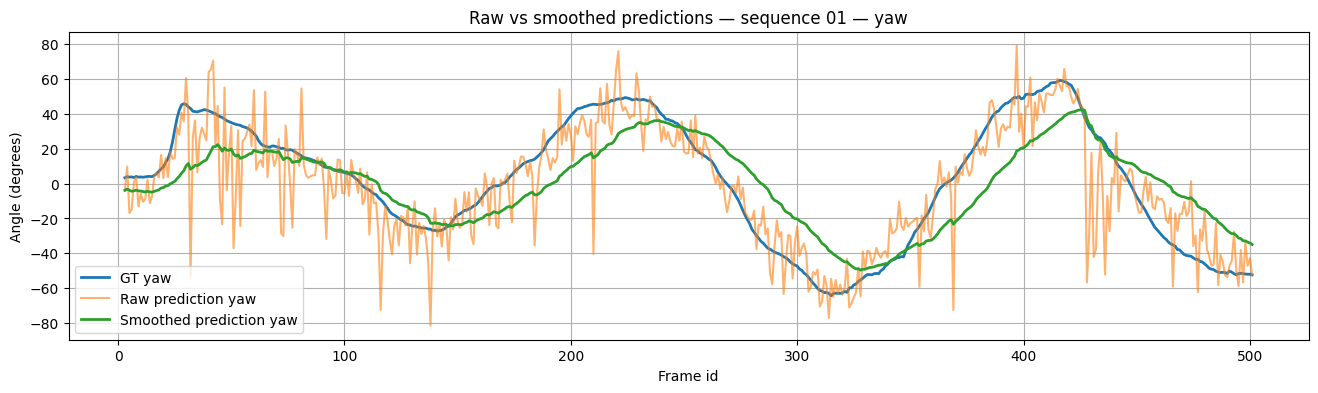

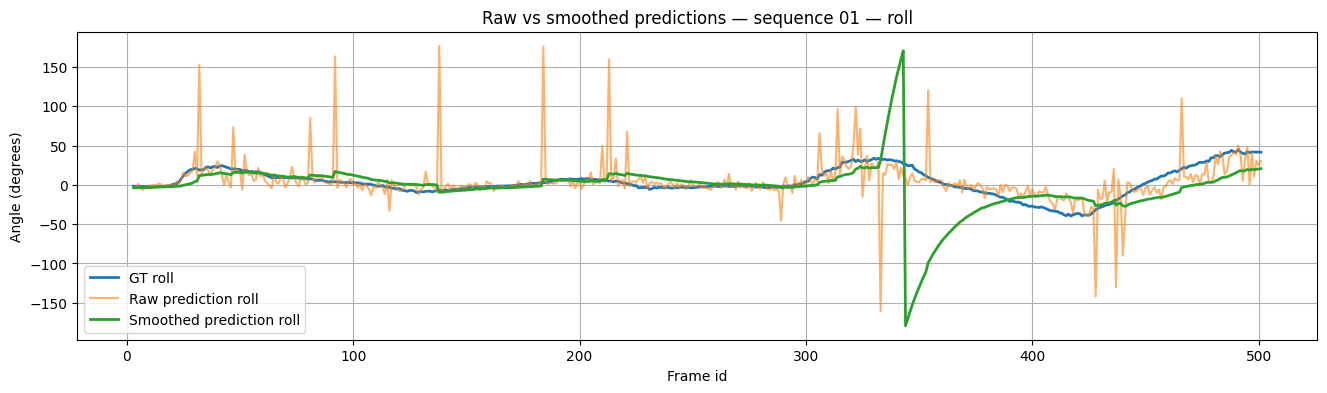

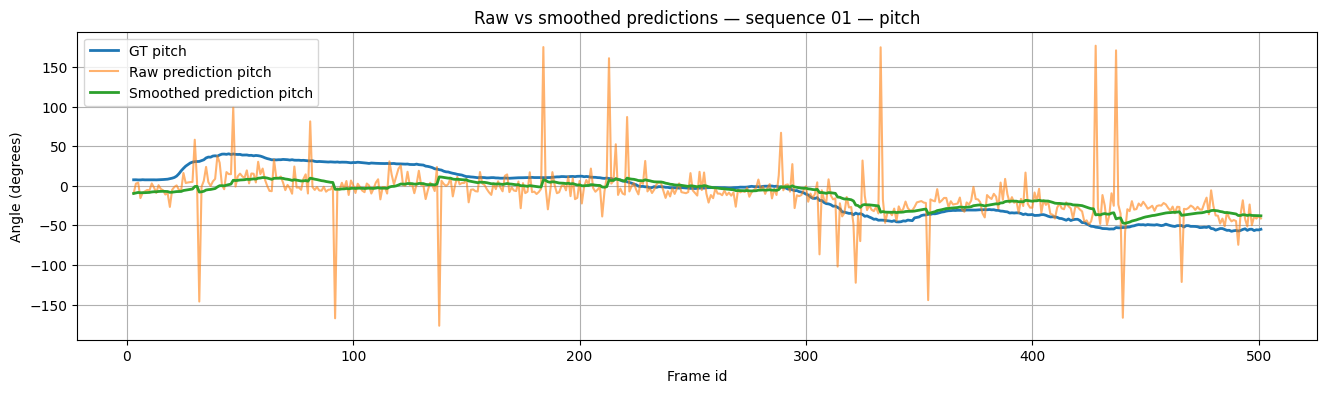

In [35]:
import matplotlib.pyplot as plt

# Choose a representative test sequence
plot_sequence_id = 1

plot_df = (
    final_smoothed_df[final_smoothed_df["sequence_id"] == plot_sequence_id]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print(f"Visualizing sequence {plot_sequence_id:02d}")
print("Number of frames:", len(plot_df))

for angle in ["yaw", "roll", "pitch"]:
    plt.figure(figsize=(16, 4))
    
    plt.plot(
        plot_df["frame_id"],
        plot_df[angle],
        label=f"GT {angle}",
        linewidth=2
    )
    
    plt.plot(
        plot_df["frame_id"],
        plot_df[f"pred_{angle}"],
        label=f"Raw prediction {angle}",
        alpha=0.6
    )
    
    plt.plot(
        plot_df["frame_id"],
        plot_df[f"smooth_pred_{angle}"],
        label=f"Smoothed prediction {angle}",
        linewidth=2
    )
    
    plt.xlabel("Frame id")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Raw vs smoothed predictions — sequence {plot_sequence_id:02d} — {angle}")
    plt.legend()
    plt.grid(True)
    plt.show()